# 4112 simulation with coherent errors

Import the Kraus operators of the noisy channel from the qutip simulation.

After the simulation, check the overall logical error rate: what is the dependence?

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error, QuantumError, kraus_error
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix, Pauli, Kraus, Operator
from qiskit.circuit.library import RZZGate  # exp(-i phi/2 Z\otimes Z)

import numpy as np
import itertools

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.linalg import sqrtm, inv, ishermitian, eigh

import numpy.typing as npt
from typing import Tuple, Any

from qutip import *
from processTomography import *
from qutip.measurement import measure, measurement_statistics

### Check: A regular 4112 plus state preparation scheme

In [28]:
qubits = np.array(range(8))
data = qubits[2:6]   # 4 qubits in the middle: data
ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla

for q in ancilla:
    print(q)

0
1
6
7


In [29]:
# Initialization
p_dep = 0.00

# Step 1: Build the ideal circuit

qubits = np.array(range(8))
data = qubits[2:6]   # 4 qubits in the middle: data
ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
cr = np.zeros((1,4))   # register for the intermediate circuit measurement

qc = QuantumCircuit(8)
# plus state preparation
for q in data:
    qc.reset(q)
qc.h(data[0])
qc.h(data[2])
qc.id(data[1])
qc.id(data[3])
qc.cx(data[0],data[1])
qc.cx(data[2],data[3])

# add noisy ZZ rotation gate here

# ZX-QED
# t-1 (can be done with former circuits)
qc.reset(ancilla[0])
qc.reset(ancilla[1])
qc.barrier()
# t0
qc.cx(data[0],ancilla[0])
qc.cx(data[2],ancilla[1])
qc.id(data[1])
qc.id(data[3])
qc.reset(ancilla[2])
qc.reset(ancilla[3])
qc.barrier()
# t1
qc.cx(data[1],ancilla[0])
qc.cx(data[3],ancilla[1])
qc.id(data[0])
qc.id(data[2])
qc.h(ancilla[2])
qc.h(ancilla[3])
qc.barrier()
# t2
# qc.measure(ancilla[0],cr[0])
# qc.measure(ancilla[1],cr[1])
qc.cx(ancilla[2],data[0])
qc.cx(ancilla[3],data[1])
qc.id(data[2])
qc.id(data[3])
qc.barrier()
# t3
qc.id(data[0])
qc.id(data[1])
qc.cx(ancilla[2],data[2])
qc.cx(ancilla[3],data[3])
qc.barrier()
# t4
qc.id(data[0])
qc.id(data[1])
qc.id(data[2])
qc.id(data[3])
qc.h(ancilla[2])
qc.h(ancilla[3])
qc.barrier()
# t5
# qc.measure(ancilla[2],cr[2])
# qc.measure(ancilla[3],cr[3]) # postpone all the measurements

# Step 2: Add depolarizing noise

# QuantumError objects
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'])


# Step 3: Simulate the circuit to get the density matrix
sim = AerSimulator(method='density_matrix', noise_model=noise_model)
qc.save_density_matrix()
compiled = transpile(qc, sim)
result = sim.run(compiled).result()
rho = result.data(0)['density_matrix']

# Step 4: Convert to Qiskit's DensityMatrix object
from qiskit.quantum_info import DensityMatrix
dm = DensityMatrix(rho)

# Step 5: Measure qubits 0, 1, 6, 7 in Z basis
# Simulate measurement by projecting onto computational basis states
def project_and_trace(dm, outcome, measured_qubits):
    """Project onto a computational basis outcome and trace out measured qubits."""
    from qiskit.quantum_info import partial_trace, Statevector
    n = dm.num_qubits
    outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
    projector = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(2**n):
        bits = format(i, f'0{n}b')
        bits = bits[::-1]
        if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
            projector[i, i] = 1
    projected_dm = projector @ dm.data @ projector
    norm = np.trace(projected_dm.data)
    if norm > 0:
        projected_dm = DensityMatrix(projected_dm.data / norm)
        reduced_dm = partial_trace(projected_dm, measured_qubits)
        return reduced_dm
    else:
        return None

# Step 6: Post-select on outcomes '0000' and '0011'
measured_qubits = [0, 1, 6, 7]
outcomes = {'0000': 0b0000, '0011': 0b0011}
reduced_dms = {}

for label, outcome in outcomes.items():
    reduced_dm = project_and_trace(dm, outcome, measured_qubits)
    if reduced_dm:
        reduced_dms[label] = reduced_dm

# # Step 7: Display results
# for label, rdm in reduced_dms.items():
#     print(f"\nReduced density matrix for outcome '{label}':")
#     print(np.round(rdm.data, 4))


In [30]:
qc.draw()

░ ┌───┐      ░ ┌───┐           ░                 ░      »
q_0: ─|0>────────────░─┤ X ├──────░─┤ X ├───────────░─────────────────░──────»
                     ░ └─┬─┘┌───┐ ░ └─┬─┘┌───┐      ░                 ░      »
q_1: ─|0>────────────░───┼──┤ X ├─░───┼──┤ X ├──────░─────────────────░──────»
          ┌───┐      ░   │  └─┬─┘ ░   │  └─┬─┘┌───┐ ░ ┌───┐           ░ ┌───┐»
q_2: ─|0>─┤ H ├──■───░───■────┼───░───┼────┼──┤ I ├─░─┤ X ├───────────░─┤ I ├»
          ├───┤┌─┴─┐ ░ ┌───┐  │   ░   │    │  └───┘ ░ └─┬─┘┌───┐      ░ ├───┤»
q_3: ─|0>─┤ I ├┤ X ├─░─┤ I ├──┼───░───■────┼────────░───┼──┤ X ├──────░─┤ I ├»
          ├───┤└───┘ ░ └───┘  │   ░ ┌───┐  │        ░   │  └─┬─┘┌───┐ ░ ├───┤»
q_4: ─|0>─┤ H ├──■───░────────■───░─┤ I ├──┼────────░───┼────┼──┤ I ├─░─┤ X ├»
          ├───┤┌─┴─┐ ░ ┌───┐      ░ └───┘  │        ░   │    │  ├───┤ ░ └─┬─┘»
q_5: ─|0>─┤ I ├┤ X ├─░─┤ I ├──────░────────■────────░───┼────┼──┤ I ├─░───┼──»
          └───┘└───┘ ░ └───┘      ░ ┌───┐           ░   │    │  └───┘ ░   │  »
q_6: ────────────────░──|0>───────░─┤ H ├───────────░───■────┼────────░───■──»
                     ░            ░ ├───┤           ░        │        ░      »
q_7: ────────────────░──|0>───────░─┤ H ├───────────░────────■────────░──────»
                     ░            ░ └───┘           ░                 ░      »
«           ░       ░  density_matrix 
«q_0: ──────░───────░────────░────────
«           ░       ░        ░        
«q_1: ──────░───────░────────░────────
«           ░ ┌───┐ ░        ░        
«q_2: ──────░─┤ I ├─░────────░────────
«           ░ ├───┤ ░        ░        
«q_3: ──────░─┤ I ├─░────────░────────
«           ░ ├───┤ ░        ░        
«q_4: ──────░─┤ I ├─░────────░────────
«     ┌───┐ ░ ├───┤ ░        ░        
«q_5: ┤ X ├─░─┤ I ├─░────────░────────
«     └─┬─┘ ░ ├───┤ ░        ░        
«q_6: ──┼───░─┤ H ├─░────────░────────
«       │   ░ ├───┤ ░        ░        
«q_7: ──■───░─┤ H ├─░────────░────────
«           ░ └───┘ ░        ░

In [ ]:
n=8
measured_qubits = [0,1,6,7]
outcome = 0b0011
outcome_bin= format(outcome, f'0{len(measured_qubits)}b')
projector = np.zeros((2**n, 2**n), dtype=complex)
for i in range(2**n):
    bits = format(i, f'0{n}b')
    bits_inv = bits[::-1]
    if all(bits_inv[q] == b for q, b in zip(measured_qubits, outcome_bin)):
        projector[i, i] = 1

projector

In [181]:
bits = format(3, f'0{8}b')
bits= bits[::-1]
bits

'11000000'

In [31]:
# Project the density matrix to the [[4,1,2]] code space

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X

def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None):
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0


# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm, pauli):
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm, logical_paulis):
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)


In [ ]:
# Example usage:
reduced_dm = reduced_dms['0000'] # Your 4-qubit density matrix
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]
post_dm, prob = projective_measurement(reduced_dm, stabilizers)
print("Probability in code space:", prob)
print("Post-measurement state:\n", post_dm)

logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
print("Logical qubit density matrix:")
print(logical_dm)

In [156]:
# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(phi):
    # |+> state
    plus = np.array([[1], [1]]) / np.sqrt(2)
    # Rz(phi) = exp(i * phi * Z)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Function to compute trace distance
def trace_distance(rho, sigma):
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.sum(np.abs(eigvals))

# Example: replace this with your logical density matrix
# logical_dm = DensityMatrix(...)  # from logical_subspace_tomography()

# Set the rotation angle phi (in radians)
# phi = np.pi / 4  # Example: pi/4
phi = 0

# Compute the ideal state
ideal_dm = ideal_state_density_matrix(phi)

# Compute trace distance
distance = trace_distance(logical_dm, ideal_dm)
print(f"Trace distance to Rz({phi})|+>: {distance:.4f}")


Trace distance to Rz(0)|+>: 0.0000


#### Sweep the error rate: check the dependence between trace distance and p_dep

In [34]:
# all the functions for the trace distance calculation

# circuit to generate the output density matrix with given syndrome outcome
def circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]:
    # Step 1: Build the ideal circuit
    qubits = np.array(range(8))
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    cr = np.zeros((1,4))   # register for the intermediate circuit measurement

    qc = QuantumCircuit(8)
    # plus state preparation
    for q in data:
        qc.reset(q)
    qc.h(data[0])
    qc.h(data[2])
    qc.id(data[1])
    qc.id(data[3])
    qc.cx(data[0],data[1])
    qc.cx(data[2],data[3])

    # add noisy ZZ rotation gate here

    # ZX-QED
    # t-1 (can be done with former circuits)
    qc.reset(ancilla[0])
    qc.reset(ancilla[1])
    # t0
    qc.cx(data[0],ancilla[0])
    qc.cx(data[2],ancilla[1])
    qc.id(data[1])
    qc.id(data[3])
    qc.reset(ancilla[2])
    qc.reset(ancilla[3])
    # t1
    qc.cx(data[1],ancilla[0])
    qc.cx(data[3],ancilla[1])
    qc.id(data[0])
    qc.id(data[2])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t2
    # qc.measure(ancilla[0],cr[0])
    # qc.measure(ancilla[1],cr[1])
    qc.cx(ancilla[2],data[0])
    qc.cx(ancilla[3],data[1])
    qc.id(data[2])
    qc.id(data[3])
    # t3
    qc.id(data[0])
    qc.id(data[1])
    qc.cx(ancilla[2],data[2])
    qc.cx(ancilla[3],data[3])
    # t4
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])
    qc.id(data[3])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t5
    # qc.measure(ancilla[2],cr[2])
    # qc.measure(ancilla[3],cr[3]) # postpone all the measurements

    # Step 2: Add depolarizing noise

    # QuantumError objects
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'])
    # add noise for the ZZ rotation gate

    # Step 3: Simulate the circuit to get the density matrix
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    qc.save_density_matrix()
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    rho = result.data(0)['density_matrix']

    # Step 4: Convert to Qiskit's DensityMatrix object
    dm = DensityMatrix(rho)

    # Step 5: Measure qubits 0, 1, 6, 7 in Z basis
    # Simulate measurement by projecting onto computational basis states
    def project_and_trace(dm: DensityMatrix, outcome: str, measured_qubits: list[int]) -> tuple[DensityMatrix, float]:   ### CHECK!!!
        """Project onto a computational basis outcome and trace out measured qubits."""
        from qiskit.quantum_info import partial_trace, Statevector
        n = dm.num_qubits
        outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
        projector = np.zeros((2**n, 2**n), dtype=complex)
        for i in range(2**n):
            bits = format(i, f'0{n}b')
            bits = bits[::-1]
            if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
                projector[i, i] = 1
        projected_dm = projector @ dm.data @ projector
        norm = np.trace(projected_dm.data)
        if norm > 0:
            projected_dm = DensityMatrix(projected_dm.data / norm)
            reduced_dm = partial_trace(projected_dm, measured_qubits)
            return reduced_dm, norm
        else:
            return None, 0

    # Step 6: Post-select on outcomes '0000' and '0011'
    measured_qubits = [ancilla[0], ancilla[1], ancilla[2], ancilla[3]]
    outcomes = {'0000': 0b0000, '0011': 0b0011}
    # outcomes = {'0000': 0b0000, '0011': 0b0011, '1100': 0b1100, '1111': 0b1111}
    reduced_dms = {}
    prob_list={}

    for label, outcome in outcomes.items():
        reduced_dm, norm = project_and_trace(dm, outcome, measured_qubits)
        if reduced_dm:
            reduced_dms[label] = reduced_dm
            prob_list[label] = np.real(norm)
    
    return reduced_dms, prob_list

# project the state to the code space
def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None) -> tuple[DensityMatrix,float]:
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2   # check!!!!

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0

# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm:DensityMatrix, pauli:Pauli) -> float:
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm:DensityMatrix, logical_paulis:Pauli) -> DensityMatrix:
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)

# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(ph:float) -> DensityMatrix:
    plus = np.array([[1], [1]]) / np.sqrt(2)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Compute trace distance
def trace_distance(rho:DensityMatrix, sigma:DensityMatrix) -> float:
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.real( np.sum(np.abs(eigvals)) )

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X


# Sweep p_dep and compute trace distances
# phi = np.pi / 4
phi = 0
ideal_dm = ideal_state_density_matrix(phi)
p_dep_values = np.logspace(-4, np.log10(4e-3), num=20)
trace_distances = []

for p_dep in p_dep_values:
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    reduced_dms, prob_list = circuit_generation(p_dep)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'0000','0011'}
    stab_value_dict = {'0000':[0,0,0], '0011':[1,1,0]}
    trace_distance_dict= {'0000':0, '0011':0}
    cond_prob_dict = {'0000':prob_list['0000']/success_prob, '0011':prob_list['0011']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances.append(distance)

# Output results
print("Noise parameters (p_dep):", p_dep_values)
print("Trace distances:", trace_distances)

Noise parameters (p_dep): [0.0001     0.00012143 0.00014745 0.00017904 0.00021741 0.00026399
 0.00032056 0.00038925 0.00047266 0.00057395 0.00069693 0.00084627
 0.00102761 0.0012478  0.00151518 0.00183986 0.0022341  0.00271283
 0.00329413 0.004     ]
Trace distances: [3.376046936454103e-08, 4.9782331534853355e-08, 7.340880792128247e-08, 1.0825017776605603e-07, 1.5963134747387642e-07, 2.3540669435995204e-07, 3.471625539264168e-07, 5.119920934437693e-07, 7.551155941643015e-07, 1.1137498723279291e-06, 1.6428241613741794e-06, 2.4234268921619058e-06, 3.5752940253930277e-06, 5.2752832971902936e-06, 7.784722478199056e-06, 1.1489928088082026e-05, 1.6962297774925084e-05, 2.5047540142875132e-05, 3.6998363423967895e-05, 5.4672134448763274e-05]


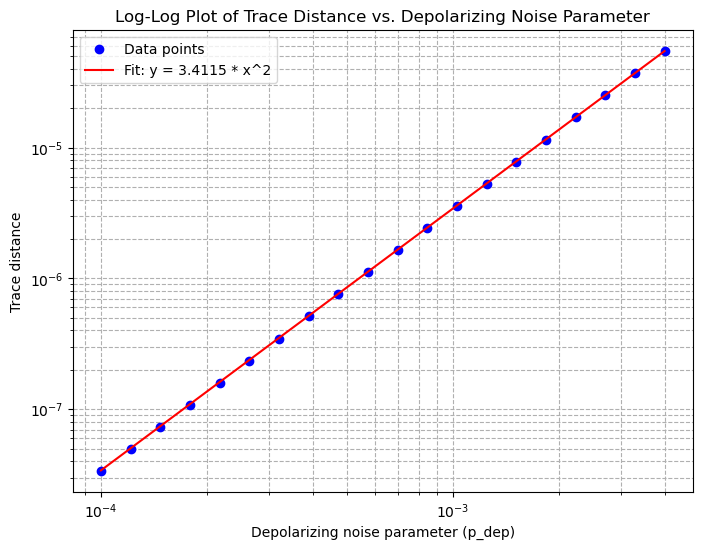

In [35]:
# Example data
# p_dep_values = np.logspace(-4, np.log10(4e-3), num=10)
# trace_distances = [0.0001, 0.0002, 0.0004, 0.0008, 0.0016, 0.0032, 0.0064, 0.0128, 0.0256, 0.0512]

# Define the quadratic model y = k * x^2
def quadratic_model(x, k):
    return k * x**2

# Fit the model to the data
params, _ = curve_fit(quadratic_model, p_dep_values, trace_distances)
k = params[0]

# Generate the fitting curve
fitting_curve = quadratic_model(p_dep_values, k)

# Create the log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(p_dep_values, trace_distances, 'bo', label='Data points')
plt.loglog(p_dep_values, fitting_curve, 'r-', label=f'Fit: y = {k:.4f} * x^2')
plt.xlabel('Depolarizing noise parameter (p_dep)')
plt.ylabel('Trace distance')
plt.title('Log-Log Plot of Trace Distance vs. Depolarizing Noise Parameter')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


### Add ZZ-rotation gate and coherent error

#### Without ancilla case

In [78]:
from qutip import *
from processTomography import *
from qutip.measurement import measure, measurement_statistics

##### First get the kraus operators

In [4]:
# calculate the propagator of the dispersive coupling procedure
def Propagator_ZZrotNaiveNoisy(phi:float, chi_ZZ: float, kappa0:float) -> Qobj:
    '''
    Calculate the propagator of the ancilla-free noisy ZZ rotation gate.

    Parameters:
    -----------------------------------
    Input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    
    Output:
    L_naiveZZrot: ([2,2]*[2,2])*([2,2]*[2,2]) Qobj: the Liouville matrix to store the propagator
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_12 = -chi_ZZ*tensor( sigmaz(), sigmaz() )

    # (normalized) jump operators
    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1))

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-11, rtol=1e-11)
    
    # then perform the first-round dispersive coupling ZZ gates 
    # times = np.linspace(0, (phi/chi_ZZ), 1000)
    # result = mesolve(HZZ_12, rho0, times, c_ops, [], options=options)
    # rho1 = result.states[-1].unit()

    time = phi/chi_ZZ

    L_naiveZZrot = propagator(HZZ_12, time, c_ops, [], options=options)

    return L_naiveZZrot


In [80]:
# test the propagator calculation
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
p_dep = 1e-3
kappa0 = 2e4

L_naiveZZrot = Propagator_ZZrotNaiveNoisy(phi, chi_ZZ, kappa0)
kraus_ops = to_kraus(L_naiveZZrot)
choi_matrix = to_choi(L_naiveZZrot)
chi_matrix = to_chi(L_naiveZZrot)

L_naiveZZrot.iscptp


C:\Users\zengp\AppData\Roaming\Python\Python311\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


True

In [41]:
# check the validity of the kraus operators

def is_cptp(kraus_ops, tol=1e-10):
    """
    Check whether a list of Kraus operators defines a CPTP map.
    
    Parameters:
    - kraus_ops: list of Qobj, the Kraus operators
    
    Returns:
    - True if the map is CPTP, False otherwise
    """
    dim = kraus_ops[0].shape[0]
    completeness = sum([K.dag() * K for K in kraus_ops])
    completeness2 = Qobj(completeness.full())
    I = identity(dim)
    return (completeness2 - I).norm() < tol

print(is_cptp(kraus_ops))


True


In [ ]:
# convert kraus_ops to numpy arrays
kraus_ops[0].full()

##### Former codes: hidden

In [ ]:
# define the circuit as a function of density matrix input to density matrix output
# define the circuit as a function of density matrix input to density matrix output
def ZZrotNaiveNoisy(rho0: Qobj, phi: float, chi_ZZ: float, kappa0:float) -> Qobj:   # tuple[int, Qobj]:
    '''
    Simulation of a parity measurement procedure based on the mesolve function.

    Parameters:
    -----------------------------------
    Input:
    rho0: [2,2]*[2,2] Qobj: initial state on two qubits : density matrix
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    p_prep: 0~1 float: state preparation noise level
    
    Output:
    rho12anc: [2,2]*[2,2] Qobj: final output state on the whole system
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_12 = -chi_ZZ*tensor( sigmaz(), sigmaz() )

    # (normalized) jump operators
    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1))

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-11, rtol=1e-11)
    
    # then perform the first-round dispersive coupling ZZ gates 
    times = np.linspace(0, (phi/chi_ZZ), 1000)
    result = mesolve(HZZ_12, rho0, times, c_ops, [], options=options)
    rho1 = result.states[-1].unit()
    
    return rho1

# function to output the chi_matrix and failure probability of the noisy ZZ-rot gate 
def ZZnoisyNaive_chi_matrix(phi: float, chi_ZZ: float, Omega: float, kappa0: float): 
    """
    Compute the 16 Pauli error rates of a two-qubit Pauli channel.
    The channel is provided as a function that takes an input density matrix
    and returns the output density matrix.
    -------------------------------
    input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    p_prep: 0~1 float: state preparation noise level

    output:
    p_fail: float, failure probability
    error_rates: float, Pauli error rates when pass the post-selection
    """

    # generate the input density matrix list
    rho_ini_list = initialDensityMatrixForProcessTomography(2)
    Psi_ini_list = initialStateVectorForProcessTomography(2)

    num_state = 4**2
    # Pfail = 0
    rho_out_list = []

    # Compute the action of the channel on each input state
    for i, rho_ini in enumerate(rho_ini_list):
        # run the noisy ZZ(phi) gate
        rho_out = ZZrotNaiveNoisy(rho_ini, phi, chi_ZZ, kappa0) 

        # output the conditional successful state
        rhoPost = 0.5 * ( rho_out +  rho_out.dag() )
        rhoPost = rhoPost/rhoPost.tr()
        rho_out_list.append(rhoPost)

    # Calculate the chi_matrix of the noise channel
    Uinv = (- 1j*phi*tensor(sigmaz(),sigmaz()) ).expm()
    rho_out_list1 = [Uinv * rho * Uinv.dag() for rho in rho_out_list]
    # rho_out_list1 = [0.7*rho + 0.3*tensor(sigmax(),sigmaz())*rho*tensor(sigmax(),sigmaz()) for rho in rho_out_list1]    # used to check the correctness of the final plot
    chi_matrix = cal_ChiMatrix(rho_out_list1)

    return chi_matrix


# Define the Pauli matrices
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Define the 16 Pauli basis elements for two qubits
pauli_basis = [
    np.kron(I, I), np.kron(I, X), np.kron(I, Y), np.kron(I, Z),
    np.kron(X, I), np.kron(X, X), np.kron(X, Y), np.kron(X, Z),
    np.kron(Y, I), np.kron(Y, X), np.kron(Y, Y), np.kron(Y, Z),
    np.kron(Z, I), np.kron(Z, X), np.kron(Z, Y), np.kron(Z, Z)
]

# Function to convert chi-matrix to Kraus operators
def chi_to_kraus(chi_matrix: np.ndarray) -> list[np.ndarray]:
    chi_matrix = np.array(chi_matrix, dtype=complex)

    chi_matrix  = 0.5 * (chi_matrix + chi_matrix.conj().T)

    # Step 1: Construct the Choi matrix
    choi_matrix = np.zeros((16, 16), dtype=complex)
    for i in range(16):
        for j in range(16):
            choi_matrix += chi_matrix[i, j] * np.outer(pauli_basis[i].flatten(order='F'), np.conj(pauli_basis[j].flatten(order='F')) )

    # Step 2: Perform spectral decomposition of the Choi matrix
    eigenvalues, eigenvectors = np.linalg.eigh(choi_matrix)

    # Step 3: Construct Kraus operators from eigenvectors with positive eigenvalues
    kraus_operators = []
    for k in range(len(eigenvalues)):
        if eigenvalues[k] > 0:
            kraus_op = np.sqrt(eigenvalues[k]) * eigenvectors[:, k].reshape(4, 4)
            kraus_operators.append(kraus_op)

    return kraus_operators

def check_chi_matrix_validity(chi_matrix: np.ndarray) -> tuple[bool, bool, float]:
    """
    Check if a chi matrix represents a valid CPTP map.
    
    For a valid quantum channel:
    1. The chi matrix must be Hermitian
    2. The chi matrix must be positive semidefinite
    3. The trace preservation condition must be satisfied:
       Tr_B[sum_{mn} chi_{mn} (P_m ⊗ P_n^*)] = I
    where P_m are the Pauli basis operators.
    
    Args:
        chi_matrix: 16x16 numpy array representing the chi matrix
        
    Returns:
        tuple: (is_valid, is_tp, trace_preservation_error)
            - is_valid: True if matrix represents valid quantum channel
            - is_tp: True if channel is trace preserving
            - trace_preservation_error: Maximum deviation from trace preservation
    """
    # Convert to numpy array if not already
    chi_matrix = np.array(chi_matrix, dtype=complex)
    
    # 1. Check Hermiticity
    is_hermitian = np.allclose(chi_matrix, chi_matrix.conj().T, atol=1e-10)
    
    # 2. Check positive semidefiniteness
    eigenvals = np.linalg.eigvalsh(chi_matrix)
    is_positive = np.all(eigenvals > -1e-10)
    
    # 3. Check trace preservation condition
    # First, construct the Choi matrix
    dim = 4  # for two qubits
    choi_matrix = np.zeros((dim**2, dim**2), dtype=complex)
    for i in range(16):
        for j in range(16):
            choi_matrix += chi_matrix[i, j] * np.outer(pauli_basis[i].flatten(order='F'), np.conj(pauli_basis[j].flatten(order='F')) )
    
    # Partial trace over the second system should give identity
    # Reshape to 4x4x4x4 for easier partial trace
    choi_reshaped = choi_matrix.reshape(dim, dim, dim, dim)
    partial_trace = np.trace(choi_reshaped, axis1=2, axis2=3)
    
    # Check if partial trace is close to identity
    identity = np.eye(dim)
    trace_preservation_error = np.max(np.abs(partial_trace - identity))
    is_tp = np.allclose(partial_trace, identity, atol=1e-10)
    
    is_valid = is_hermitian and is_positive and is_tp
    
    return is_valid, is_hermitian, is_positive, is_tp, trace_preservation_error

In [ ]:
# Test the modified process tomography
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
p_dep = 1e-3
kappa0 = 2e4

chi_matrix = ZZnoisyNaive_chi_matrix(phi, chi_ZZ, Omega, kappa0)

# Check the properties of the resulting chi matrix
is_valid, is_hermitian, is_positive, is_tp, tp_error = check_chi_matrix_validity(chi_matrix)
print(f"Post-selected channel properties:")
# print(f"Average failure probability: {pfail:.6f}")
print(f"Is valid quantum channel: {is_valid}")
print(f"Is trace preserving: {is_tp}")
print(f"Is Hermitian: {is_hermitian}")
print(f"Is positive: {is_positive}")
print(f"Trace preservation error: {tp_error:.2e}")

if not is_tp:
    print("\nNote: Non-trace-preservation is expected for post-selected channels!")
    # print(f"The channel preserves {1-pfail:.2%} of the trace on average.")


In [ ]:
sum_main = sum(chi_matrix[i][i] for i in range(chi_matrix.shape[0]))

print(f"Trace of the chi matrix: {sum(chi_matrix[i][i] for i in range(chi_matrix.shape[0]))}")

choi_matrix = np.zeros((16, 16), dtype=complex)
for i in range(16):
    for j in range(16):
        choi_matrix += chi_matrix[i, j] * np.outer(pauli_basis[i].flatten(order='F'), np.conj(pauli_basis[j].flatten(order='F')) )

print(f"Trace of the choi matrix: {sum(choi_matrix[i][i] for i in range(choi_matrix.shape[0]))}")

dim = 4
choi_reshaped = choi_matrix.reshape(dim, dim, dim, dim)  # CHECK!!!

partial_trace = np.trace(choi_reshaped, axis1=2, axis2=3)
partial_trace

In [ ]:
aaa = np.outer(pauli_basis[1].flatten(order='F'), np.conj(pauli_basis[2].flatten(order='F')) )
aaa.shape

In [ ]:
kraus_operators = chi_to_kraus(chi_matrix)
# Compute residual operator
identity = np.eye(4)
sum_kdagger_k = sum([k.T.conj() @ k for k in kraus_operators])
residual = identity - sum_kdagger_k

residual

In [ ]:
eigenvals = np.linalg.eigvalsh(chi_matrix)
eigenvals

##### Run the sweep

Parameter setting: $\kappa_{fe} = \kappa_{eg} = \kappa_{\phi} = \kappa_0$

Current hardware: $p_{dep} = 1\cdot 10^{-3}, \kappa_0 = \frac{1}{50 us} = 2\cdot 10^4 s^{-1}$

In the following simulation, we set the ratio between $p_{dep}$ and $\kappa_0$ to be a constant, that is, we fix $\frac{\kappa_0}{p_{dep}} = 2\cdot 10^7  s^{-1}$

In [52]:
## Define the noisy circuit for the |m_\phi> state prepraration
# circuit to generate the output density matrix with given syndrome outcome
def circuit_generation_naive(p_dep:float, phi:float, kappa0:float,
                       chi_ZZ:float = 2*np.pi*4.8e6, Omega:float = 2*np.pi*20.4e6) -> tuple[dict[str, DensityMatrix], dict[str, float]]:
    # Step 1: Build the ideal circuit
    qubits = np.array(range(8)) 
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    cr = np.zeros((1,4))   # register for the intermediate circuit measurement

    qc = QuantumCircuit(8)
    # plus state preparation
    for q in data:
        qc.reset(q)
    qc.h(data[0])
    qc.h(data[2])
    qc.id(data[1])
    qc.id(data[3])
    qc.cx(data[0],data[1])
    qc.cx(data[2],data[3])

    # add ZZ rotation gate here
    # zz_gate = RZZGate(-2 * phi)
    # qc.append(zz_gate, [data[0], data[2]])
    L_naiveZZrot = Propagator_ZZrotNaiveNoisy(phi, chi_ZZ, kappa0)
    kraus_ops = to_kraus(L_naiveZZrot)
    kraus_matrices = [k.full() for k in kraus_ops]  # Convert Qobj to NumPy
    kraus_gate = Kraus(kraus_matrices)
    qc.append(kraus_gate, [data[0], data[2]])

    # ZX-QED
    # t-1 (can be done with former circuits)
    qc.reset(ancilla[0])
    qc.reset(ancilla[1])
    # t0
    qc.cx(data[0],ancilla[0])
    qc.cx(data[2],ancilla[1])
    qc.id(data[1])
    qc.id(data[3])
    qc.reset(ancilla[2])
    qc.reset(ancilla[3])
    # t1
    qc.cx(data[1],ancilla[0])
    qc.cx(data[3],ancilla[1])
    qc.id(data[0])
    qc.id(data[2])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t2
    # qc.measure(ancilla[0],cr[0])
    # qc.measure(ancilla[1],cr[1])
    qc.cx(ancilla[2],data[0])
    qc.cx(ancilla[3],data[1])
    qc.id(data[2])
    qc.id(data[3])
    # t3
    qc.id(data[0])
    qc.id(data[1])
    qc.cx(ancilla[2],data[2])
    qc.cx(ancilla[3],data[3])
    # t4
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])
    qc.id(data[3])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t5
    # qc.measure(ancilla[2],cr[2])
    # qc.measure(ancilla[3],cr[3]) # postpone all the measurements

    # Step 2: Add noise

    # QuantumError objects
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'])

    # append ZZ noise as an instruction (CP non-TP channel)
    # chi_matrix = ZZnoisyNaive_chi_matrix(phi, chi_ZZ, Omega, kappa0)  # pfail_ZZ here is useless
    # kraus_operators = chi_to_kraus(chi_matrix)
    # kraus_channel = Kraus(kraus_operators)
    # zz_error = QuantumError(kraus_channel)
    # noise_model.add_quantum_error(zz_error, zz_gate.name, [data[0], data[2]])  # note that this error is non-TP!
    
    
    # Step 3: Simulate the circuit to get the density matrix
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    qc.save_density_matrix()
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    rho = result.data(0)['density_matrix']

    # Step 4: Convert to Qiskit's DensityMatrix object
    dm = DensityMatrix(rho)

    # Step 5: Measure qubits 0, 1, 6, 7 in Z basis
    # Simulate measurement by projecting onto computational basis states
    def project_and_trace(dm: DensityMatrix, outcome: str, measured_qubits: list[int]) -> tuple[DensityMatrix, float]:
        """Project onto a computational basis outcome and trace out measured qubits."""
        from qiskit.quantum_info import partial_trace, Statevector
        n = dm.num_qubits
        outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
        projector = np.zeros((2**n, 2**n), dtype=complex)
        for i in range(2**n):
            bits = format(i, f'0{n}b')
            bits = bits[::-1]
            if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
                projector[i, i] = 1
        projected_dm = projector @ dm.data @ projector
        norm = np.trace(projected_dm.data)
        if norm > 0:
            projected_dm = DensityMatrix(projected_dm.data / norm)
            reduced_dm = partial_trace(projected_dm, measured_qubits)
            return reduced_dm, norm
        else:
            return None, 0

    # Step 6: Post-select on outcomes '0000' and '0011'
    measured_qubits = [ancilla[0], ancilla[1], ancilla[2], ancilla[3]]
    outcomes = {'0000': 0b0000, '0011': 0b0011}
    reduced_dms = {}
    prob_list={}

    for label, outcome in outcomes.items():
        reduced_dm, norm = project_and_trace(dm, outcome, measured_qubits)
        if reduced_dm:
            reduced_dms[label] = reduced_dm
            prob_list[label] = np.real(norm)
    
    return reduced_dms, prob_list

# project the state to the code space
def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None) -> tuple[DensityMatrix,float]:
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0

# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm:DensityMatrix, pauli:Pauli) -> float:
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm:DensityMatrix, logical_paulis:Pauli) -> DensityMatrix:
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)

# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(ph:float) -> DensityMatrix:
    plus = np.array([[1], [1]]) / np.sqrt(2)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Compute trace distance
def trace_distance(rho:DensityMatrix, sigma:DensityMatrix) -> float:
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.real( np.sum(np.abs(eigvals)) )

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X

In [53]:
# Sweep p_dep and compute trace distances
# phi = np.pi / 4
phi = np.pi/8
chi_ZZ:float = 2*np.pi*4.8e6
Omega:float = 2*np.pi*20.4e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep_values = np.logspace(-4, np.log10(4e-3), num=10)
trace_distances_pi8_naive = []

for p_dep in p_dep_values:
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation_naive(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'0000','0011'}
    stab_value_dict = {'0000':[0,0,0], '0011':[1,1,0]}
    trace_distance_dict= {'0000':0, '0011':0}
    cond_prob_dict = {'0000':prob_list['0000']/success_prob, '0011':prob_list['0011']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi8_naive.append(distance)

# Output results
print("Noise parameters (p_dep):", p_dep_values)
print("Trace distances:", trace_distances_pi8_naive)

Noise parameters (p_dep): [0.0001     0.00015066 0.00022699 0.000342   0.00051526 0.00077631
 0.00116961 0.00176217 0.00265493 0.004     ]
Trace distances: [3.935773242090992e-08, 8.935448035483225e-08, 2.0314734538547084e-07, 4.612311267221986e-07, 1.0474636069876697e-06, 2.3795356570002693e-06, 5.407927690380463e-06, 1.2298171089578241e-05, 2.7993302153113766e-05, 6.380762475195666e-05]


In [26]:
phi = np.pi/8
chi_ZZ:float = 2*np.pi*4.8e6
Omega:float = 2*np.pi*20.4e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep = 1e-4
kappa0 = p_dep*2e7
reduced_dms, prob_list = circuit_generation_naive(p_dep, phi, kappa0, chi_ZZ, Omega)
success_prob = sum(prob_list.values())
failure_prob = 1 - success_prob

print("failure_prob:", failure_prob)

prob_list

failure_prob: 0.0015234810591953085


{'0000': 0.49923825947040235, '0011': 0.49923825947040235}

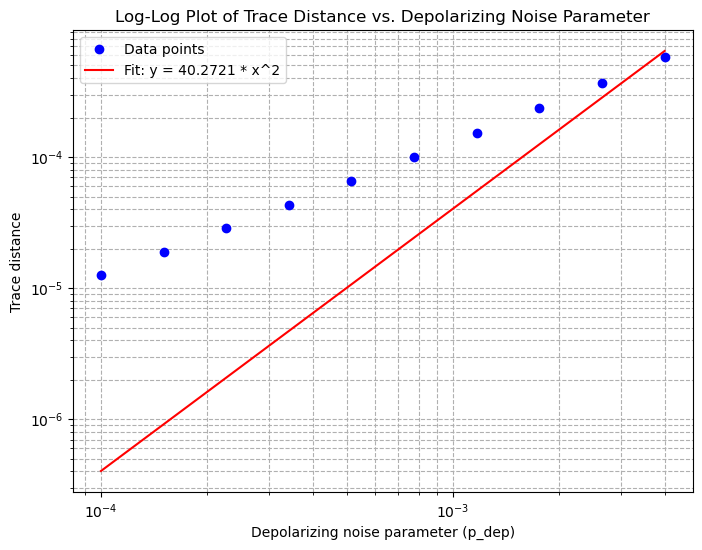

In [27]:
# Example data
# p_dep_values = np.logspace(-4, np.log10(4e-3), num=10)
# trace_distances = [0.0001, 0.0002, 0.0004, 0.0008, 0.0016, 0.0032, 0.0064, 0.0128, 0.0256, 0.0512]

# Define the quadratic model y = k * x^2
def quadratic_model(x, k):
    return k * x**2

# Fit the model to the data
params, _ = curve_fit(quadratic_model, p_dep_values, trace_distances_pi8_naive)
k = params[0]

# Generate the fitting curve
fitting_curve = quadratic_model(p_dep_values, k)

# Create the log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(p_dep_values, trace_distances_pi8_naive, 'bo', label='Data points')
plt.loglog(p_dep_values, fitting_curve, 'r-', label=f'Fit: y = {k:.4f} * x^2')
plt.xlabel('Depolarizing noise parameter (p_dep)')
plt.ylabel('Trace distance')
plt.title('Log-Log Plot of Trace Distance vs. Depolarizing Noise Parameter')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

#### With ancilla case

In [11]:
from qutip import *
from processTomography import *
from qutip.measurement import measure, measurement_statistics

In [49]:
%reset

##### First get the kraus operators

In [4]:
# calculate the propagator of the dispersive coupling procedure
def Propagator_ZZrot_gfNoisy(phi:float, chi_ZZ: float, Omega:float, kappa0:float) -> Qobj:
    '''
    Calculate the propagator of the ancilla-free noisy ZZ rotation gate.

    Parameters:
    -----------------------------------
    Input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    
    Output:
    L_gfZZrot: ([2,2,3]*[2,2,3])*([2,2,3]*[2,2,3]) Qobj: the Liouville matrix to store the propagator
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    ## operators definition
    # Pauli operators on the three-level system: defined on the g, f levels
    Xgf = projection(3,0,2) + projection(3,2,0)
    Ygf = -1j*projection(3,0,2) + 1j*projection(3,2,0)
    Zgf = projection(3,0,2) - projection(3,2,0)

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_1anc = chi_ZZ*tensor( projection(2,1,1), identity(2), projection(3,2,2) )
    HZZ_2anc = chi_ZZ*tensor( identity(2), projection(2,1,1), projection(3,2,2) )
    HY_anc = Omega*tensor( identity(2), identity(2), Ygf)
    HX_anc = Omega*tensor( identity(2), identity(2), Xgf)

    # (normalized) jump operators
    # ancilla jump operators
    J_anc_fe = tensor(identity(2), identity(2), projection(3,1,2)) # f-> e decay without coupling
    J_anc_eg = tensor(identity(2), identity(2), projection(3,0,1)) # e-> g decay without coupling
    J_anc_ph = tensor(identity(2), identity(2), projection(3,1,1) + 2*projection(3,2,2))

    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2), identity(3)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2), identity(3))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1), identity(3)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1), identity(3))


    # # ancilla (noisy) initial state preparation
    # rho_anc0 = (1-p_prep)*projection(3,0,0) + p_prep*projection(3,1,1)
    # rho_ini = tensor(rho0, rho_anc0)  # the global initial state

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_anc_fe,
        np.sqrt(kappa_d) * J_anc_eg,
        np.sqrt(kappa_ph) * J_anc_ph,
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-10, rtol=1e-10)
    # first convert the ancilla to the g+-f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(HY_anc, rho_ini, times, c_ops[0:3], [], options=options)# no data qubit noise: because we can perform this gate in advance
    # rho1 = result.states[-1].unit()
    time = (np.pi/4) / Omega
    L_step1 = propagator(HY_anc, time, c_ops[0:3], [], options=options)
    
    # then perform the first-round dispersive coupling ZZ gates 
    ''' 
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho1, times, c_ops, [], options=options)
    rho2 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho2, times, c_ops, [], options=options)
    rho3 = result.states[-1].unit() 
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho1, times, c_ops, [], options=options)
    # rho3 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step23 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)


    # then perform X-rotation on the ancillary 3-level system
    # times = np.linspace(0, (phi/Omega), 1000)
    # result = mesolve(-HX_anc, rho3, times, c_ops, [], options=options)
    # rho4 = result.states[-1].unit()
    time = phi/Omega
    L_step4 = propagator(-HX_anc, time, c_ops, [], options=options)


    # then perform the second-round dispersive coupling ZZ gates
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho4, times, c_ops, [], options=options)
    rho5 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho5, times, c_ops, [], options=options)
    rho6 = result.states[-1].unit()
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho4, times, c_ops, [], options=options)
    # rho6 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step56 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)
    

    # finally convert the ancilla to the g e f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(-HY_anc, rho6, times, c_ops[0:3], [], options=options) # no data qubit noise: because we can perform this gate simultaneously with data qubit latter operations
    # rho7 = result.states[-1].unit()
    # rho12anc = rho7
    time = (np.pi/4) / Omega
    L_step7 = propagator(-HY_anc, time, c_ops[0:3], [], options=options)    

    L_gfZZrot = L_step7 * L_step56 * L_step4 * L_step23 * L_step1

    return L_gfZZrot

Before the qiskit circuit simulation, we need to first extend the 2-qubit + 1-qutrit kraus channel to 4-qubit channel: qiskit does not have a good support on the qutrit circuit.

We extend the Propagator definition.

We set: $ \ket{0} \to \ket{00}, \ket{1} \to \ket{01}, \ket{2} \to \ket{11} $.

In [12]:
# calculate the propagator of the dispersive coupling procedure
def Propagator_ZZrot_gfNoisy_extend(phi:float, chi_ZZ: float, Omega:float, kappa0:float) -> Qobj:
    '''
    Calculate the propagator of the ancilla-free noisy ZZ rotation gate.

    Parameters:
    -----------------------------------
    Input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    
    Output:
    L_gfZZrot: ([2,2,4]*[2,2,4])*([2,2,4]*[2,2,4]) Qobj: the Liouville matrix to store the propagator
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    ## operators definition
    # Pauli operators on the three-level system: defined on the g, f levels
    # Extension: 0: 00 => 0; 1: 01 => 1; 2: 11 => 3
    Xgf = projection(4,0,3) + projection(4,3,0)
    Ygf = -1j*projection(4,0,3) + 1j*projection(4,3,0)
    Zgf = projection(4,0,0) - projection(4,3,3)

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_1anc = chi_ZZ*tensor( projection(2,1,1), identity(2), projection(4,3,3) )
    HZZ_2anc = chi_ZZ*tensor( identity(2), projection(2,1,1), projection(4,3,3) )
    HY_anc = Omega*tensor( identity(2), identity(2), Ygf )
    HX_anc = Omega*tensor( identity(2), identity(2), Xgf )

    # (normalized) jump operators
    # ancilla jump operators
    J_anc_fe = tensor(identity(2), identity(2), projection(4,1,3)) # f-> e decay without coupling
    J_anc_eg = tensor(identity(2), identity(2), projection(4,0,1)) # e-> g decay without coupling
    J_anc_ph = tensor(identity(2), identity(2), projection(4,1,1) + 2*projection(4,3,3))

    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2), identity(4)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2), identity(4))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1), identity(4)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1), identity(4))


    # # ancilla (noisy) initial state preparation
    # rho_anc0 = (1-p_prep)*projection(3,0,0) + p_prep*projection(3,1,1)
    # rho_ini = tensor(rho0, rho_anc0)  # the global initial state

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_anc_fe,
        np.sqrt(kappa_d) * J_anc_eg,
        np.sqrt(kappa_ph) * J_anc_ph,
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    # first convert the ancilla to the g+-f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(HY_anc, rho_ini, times, c_ops[0:3], [], options=options)# no data qubit noise: because we can perform this gate in advance
    # rho1 = result.states[-1].unit()
    time = (np.pi/4) / Omega
    L_step1 = propagator(HY_anc, time, c_ops[0:3], [], options=options)
    
    # then perform the first-round dispersive coupling ZZ gates 
    ''' 
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho1, times, c_ops, [], options=options)
    rho2 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho2, times, c_ops, [], options=options)
    rho3 = result.states[-1].unit() 
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho1, times, c_ops, [], options=options)
    # rho3 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step23 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)


    # then perform X-rotation on the ancillary 3-level system
    # times = np.linspace(0, (phi/Omega), 1000)
    # result = mesolve(-HX_anc, rho3, times, c_ops, [], options=options)
    # rho4 = result.states[-1].unit()
    time = phi/Omega
    L_step4 = propagator(-HX_anc, time, c_ops, [], options=options)


    # then perform the second-round dispersive coupling ZZ gates
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho4, times, c_ops, [], options=options)
    rho5 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho5, times, c_ops, [], options=options)
    rho6 = result.states[-1].unit()
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho4, times, c_ops, [], options=options)
    # rho6 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step56 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)
    
    
    # finally convert the ancilla to the g e f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(-HY_anc, rho6, times, c_ops[0:3], [], options=options) # no data qubit noise: because we can perform this gate simultaneously with data qubit latter operations
    # rho7 = result.states[-1].unit()
    # rho12anc = rho7
    time = (np.pi/4) / Omega
    L_step7 = propagator(-HY_anc, time, c_ops[0:3], [], options=options)    

    L_gfZZrot = L_step7 * L_step56 * L_step4 * L_step23 * L_step1
    # L_gfZZrot = L_step1 * L_step23 * L_step4 * L_step56 * L_step7

    return L_gfZZrot

In [13]:
def renormalize_superoperator_safe(L: Qobj, regularization_eps: float = 1e-12) -> Qobj:
    """
    Renormalize a superoperator L by adjusting its Kraus operators so that
    the sum of K_i† K_i is closer to the identity. Adds regularization if needed.
    """
    kraus_ops = to_kraus(L)
    K_sum = sum([K.dag() * K for K in kraus_ops])
    K_sum_np = K_sum.full()

    # Regularize K_sum to avoid singularity
    K_sum_np += regularization_eps * np.eye(K_sum_np.shape[0])

    # Compute inverse square root safely
    try:
        K_sum_inv_sqrt_np = sqrtm(np.linalg.inv(K_sum_np))
    except np.linalg.LinAlgError:
        raise ValueError("Matrix inversion failed during renormalization.")

    # Check for NaNs or Infs
    if np.any(np.isnan(K_sum_inv_sqrt_np)) or np.any(np.isinf(K_sum_inv_sqrt_np)):
        raise ValueError("Inverse square root contains NaNs or Infs after regularization.")

    # Convert back to Qobj
    K_sum_inv_sqrt = Qobj(K_sum_inv_sqrt_np, dims=K_sum.dims)

    # Renormalize Kraus operators
    kraus_ops_renorm = [K * K_sum_inv_sqrt for K in kraus_ops]

    return kraus_to_super(kraus_ops_renorm)


def renormalize_superoperator(L: Qobj) -> Qobj:
    kraus_ops = to_kraus(L)
    K_sum = sum([K.dag() * K for K in kraus_ops])
    K_sum_np = K_sum.full()
    K_sum_inv_sqrt = Qobj(inv(sqrtm(K_sum_np)), dims=K_sum.dims)
    kraus_ops_renorm = [K * K_sum_inv_sqrt for K in kraus_ops]
    return kraus_to_super(kraus_ops_renorm)



'''
def Propagator_ZZrot_gfNoisy_extend(phi: float, chi_ZZ: float, Omega: float, kappa0: float) -> Qobj:
    kappa_d = kappa_ph = kappa0

    Xgf = projection(4, 0, 3) + projection(4, 3, 0)
    Ygf = -1j * projection(4, 0, 3) + 1j * projection(4, 3, 0)

    HZZ_1anc = chi_ZZ * tensor(projection(2, 1, 1), identity(2), projection(4, 3, 3))
    HZZ_2anc = chi_ZZ * tensor(identity(2), projection(2, 1, 1), projection(4, 3, 3))
    HY_anc = Omega * tensor(identity(2), identity(2), Ygf)
    HX_anc = Omega * tensor(identity(2), identity(2), Xgf)

    c_ops = []
    if kappa0 > 0:
        c_ops = [
            np.sqrt(kappa_d) * tensor(identity(2), identity(2), projection(4, 1, 3)),
            np.sqrt(kappa_d) * tensor(identity(2), identity(2), projection(4, 0, 1)),
            np.sqrt(kappa_ph) * tensor(identity(2), identity(2), projection(4, 1, 1) + 2 * projection(4, 3, 3)),
            np.sqrt(kappa_d) * tensor(projection(2, 0, 1), identity(2), identity(4)),
            np.sqrt(kappa_ph) * tensor(projection(2, 1, 1), identity(2), identity(4)),
            np.sqrt(kappa_d) * tensor(identity(2), projection(2, 0, 1), identity(4)),
            np.sqrt(kappa_ph) * tensor(identity(2), projection(2, 1, 1), identity(4)),
        ]

    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)

    t1 = (np.pi / 4) / Omega
    t2 = (np.pi / chi_ZZ)
    t3 = phi / Omega

    L1 = safe_propagator(HY_anc, t1, c_ops[:3] if kappa0 > 0 else [], options)
    L2 = safe_propagator(HZZ_1anc + HZZ_2anc, t2, c_ops, options)
    L3 = safe_propagator(-HX_anc, t3, c_ops, options)
    L4 = safe_propagator(HZZ_1anc + HZZ_2anc, t2, c_ops, options)
    L5 = safe_propagator(-HY_anc, t1, c_ops[:3] if kappa0 > 0 else [], options)

    return L5 * L4 * L3 * L2 * L1
'''
def safe_propagator(H, t, c_ops, options):
    L = propagator(H, t, c_ops, [], options=options)
    if not (L.iscp and L.istp):
        L = renormalize_superoperator_safe(L)
        # L = renormalize_superoperator(L)
    return L


In [14]:
# test the propagator calculation
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
# p_dep = 1e-3
# kappa0 = 2e4
kappa0 = 200

L_gfZZrot = Propagator_ZZrot_gfNoisy_extend(phi, chi_ZZ, Omega, kappa0)
kraus_ops = to_kraus(L_gfZZrot)
choi_matrix = to_choi(L_gfZZrot)
# chi_matrix = to_chi(L_gfZZrot)

L_gfZZrot.iscp

C:\Users\zengp\AppData\Roaming\Python\Python311\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


True

In [15]:
choi = to_choi(L_gfZZrot)
eigvals = choi.eigenenergies()
print("is CPTP:", L_gfZZrot.iscp)
print("Minimum eigenvalue of Choi matrix:", min(eigvals))

is CPTP: True
Minimum eigenvalue of Choi matrix: -6.911437786691113e-16


In [33]:
# check the validity of the kraus operators

def is_cptp(kraus_ops, tol=1e-10):
    """
    Check whether a list of Kraus operators defines a CPTP map.
    
    Parameters:
    - kraus_ops: list of Qobj, the Kraus operators
    
    Returns:
    - True if the map is CPTP, False otherwise
    """
    dim = kraus_ops[0].shape[0]
    completeness = sum([K.dag() * K for K in kraus_ops])
    completeness2 = Qobj(completeness.full())
    I = identity(dim)
    return (completeness2 - I).norm() < tol, (completeness2 - I).norm()

print(is_cptp(kraus_ops))

(False, 7.324857942414552e-09)


In [ ]:
# Normlize the kraus operators
def normalize_kraus(kraus_ops:list[Qobj]) -> list[Qobj] :
    # Assume kraus_ops is your list of Qobj with shape (16, 16)
    # Example: kraus_ops = [Qobj(...), Qobj(...), ...]

    # Step 1: Compute the sum of K_i† K_i
    K_sum = sum([K.dag() * K for K in kraus_ops])

    # Step 2: Compute the inverse square root of K_sum
    K_sum_np = K_sum.full()  # Convert to NumPy array
    K_sum_inv_sqrt_np = sqrtm(inv(K_sum_np))  # Compute inverse square root
    K_sum_inv_sqrt = Qobj(K_sum_inv_sqrt_np, dims=K_sum.dims)  # Convert back to Qobj

    # Step 3: Renormalize each Kraus operator
    kraus_ops_renorm = [K * K_sum_inv_sqrt for K in kraus_ops]

    # Step 4 (Optional): Verify the normalization
    K_sum_renorm = sum([K.dag() * K for K in kraus_ops_renorm])
    identity_K = qeye(K_sum_renorm.shape[0])
    error = (Qobj(K_sum_renorm.full()) - identity_K).norm()

    return kraus_ops_renorm

# print(f"Trace-preserving error after renormalization: {error:.2e}")

kraus_ops_renorm = normalize_kraus(kraus_ops)
print(is_cptp(kraus_ops_renorm))

##### Check the function of the propagator: does it realize the real ZZ rotation gate?

In [71]:
# Ideal state
Psip = ( basis(2,0) + basis(2,1) ).unit()
Psitry = tensor(Psip, Psip)
# phi = np.pi/8
PsiIdeal = ( 1j*phi*tensor(sigmaz(),sigmaz()) ).expm() * Psitry

# noisy state after post-selection
Psi = tensor( Psitry, basis(4,0) )
Rho0 = ket2dm(Psi)
Rho_out = sum([K * Rho0 * K.dag() for K in kraus_ops_renorm])

# Perform projection measurement on Rho_out: only keep the 00 outcome.
# Step 1: Define the projection operator for outcome |00⟩ on the last two qubits
proj_00 = ket2dm(basis(4,0))  # dims: [4, 4]

# Step 2: Identity on the first two qubits
I_first_two = qeye([2, 2])  # dims: [2, 2]

# Step 3: Full projection operator: I ⊗ |00⟩⟨00|
P_00 = tensor(I_first_two, proj_00)  # dims: [[2,2,4],[2,2,4]]

# Step 4: Apply the projection: ρ' = P ρ P
Rho_proj = P_00 * Rho_out * P_00

# Step 5: Normalize the post-measurement state
prob_00 = Rho_proj.tr()
if prob_00 > 0:
    Rho_proj_normalized = Rho_proj / prob_00
else:
    raise ValueError("Measurement outcome '00' has zero probability.")

# Step 6: Partial trace over the last two qubits (indices 2 and 3)
Rho_first_two = ptrace(Rho_proj_normalized, [0, 1])

# Output the result
print("Reduced state on the first two qubits conditioned on outcome '00' on the last two qubits:")

Rho_first_two

# tracedist(PsiIdeal, Rho_first_two)

Reduced state on the first two qubits conditioned on outcome '00' on the last two qubits:


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.25001578-1.98530428e-23j 0.1767767 +1.76773012e-01j
  0.1767767 +1.76773012e-01j 0.24998422+1.00680768e-11j]
 [0.1767767 -1.76773012e-01j 0.25      -1.38792999e-17j
  0.24998422+2.60995074e-16j 0.17676554-1.76765538e-01j]
 [0.1767767 -1.76773012e-01j 0.24998422-2.88752126e-16j
  0.25      -1.38790549e-17j 0.17676554-1.76765538e-01j]
 [0.24998422-1.00680768e-11j 0.17676554+1.76765538e-01j
  0.17676554+1.76765538e-01j 0.24998422-1.11120674e-27j]]

In [63]:
ket2dm(PsiIdeal)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.25     +0.j        0.1767767+0.1767767j 0.1767767+0.1767767j
  0.25     +0.j       ]
 [0.1767767-0.1767767j 0.25     +0.j        0.25     +0.j
  0.1767767-0.1767767j]
 [0.1767767-0.1767767j 0.25     +0.j        0.25     +0.j
  0.1767767-0.1767767j]
 [0.25     +0.j        0.1767767+0.1767767j 0.1767767+0.1767767j
  0.25     +0.j       ]]

In [41]:
tracedist(PsiIdeal, Rho_first_two)

0.3826877771828695

##### Decompose the function to many steps to check its functionality

In [17]:
from qutip import *
import numpy as np
from scipy.linalg import sqrtm

def renormalize_kraus(kraus_ops):
    K_sum = sum([K.dag() * K for K in kraus_ops])
    K_sum_np = K_sum.full()
    K_sum_np += 1e-12 * np.eye(K_sum_np.shape[0])  # regularization
    K_sum_inv_sqrt_np = sqrtm(np.linalg.inv(K_sum_np))
    K_sum_inv_sqrt = Qobj(K_sum_inv_sqrt_np, dims=K_sum.dims)
    return [K * K_sum_inv_sqrt for K in kraus_ops]
    # return kraus_ops

def kraus_step1_HY_anc(Omega, kappa0):
    Ygf = -1j * projection(4, 0, 3) + 1j * projection(4, 3, 0)
    HY_anc = Omega * tensor(identity(2), identity(2), Ygf)
    t1 = (np.pi / 4) / Omega
    # tlist = np.linspace(0, t1, 5)
    c_ops = []
    if kappa0 > 0:
        c_ops = [
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 3)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 0, 1)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 1) + 2 * projection(4, 3, 3)),
        ]
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    L = propagator(HY_anc, t1, c_ops, [], options=options)
    # L = propagator(HY_anc, t1, c_ops, [])
    return renormalize_kraus(to_kraus(L)), L
    # L_list = propagator(HY_anc, tlist, c_ops, [])
    # return renormalize_kraus(to_kraus(L_list[-1])), L_list[-1]

def kraus_step2_ZZ(chi_ZZ, kappa0):
    HZZ_1anc = chi_ZZ * tensor(projection(2, 1, 1), identity(2), projection(4, 3, 3))
    HZZ_2anc = chi_ZZ * tensor(identity(2), projection(2, 1, 1), projection(4, 3, 3))
    H = HZZ_1anc + HZZ_2anc
    t = (np.pi / chi_ZZ)
    c_ops = []
    if kappa0 > 0:
        c_ops = [
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 3)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 0, 1)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 1) + 2 * projection(4, 3, 3)),
            np.sqrt(kappa0) * tensor(projection(2, 0, 1), identity(2), identity(4)),
            np.sqrt(kappa0) * tensor(projection(2, 1, 1), identity(2), identity(4)),
            np.sqrt(kappa0) * tensor(identity(2), projection(2, 0, 1), identity(4)),
            np.sqrt(kappa0) * tensor(identity(2), projection(2, 1, 1), identity(4)),
        ]
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    L = propagator(H, t, c_ops, [], options=options)
    # L = propagator(H, t, c_ops, [])
    return renormalize_kraus(to_kraus(L)), L

def kraus_step3_HX_anc(phi, Omega, kappa0):
    Xgf = projection(4, 0, 3) + projection(4, 3, 0)
    HX_anc = Omega * tensor(identity(2), identity(2), Xgf)
    t = phi / Omega
    c_ops = []
    if kappa0 > 0:
        c_ops = [
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 3)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 0, 1)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 1) + 2 * projection(4, 3, 3)),
            np.sqrt(kappa0) * tensor(projection(2, 0, 1), identity(2), identity(4)),
            np.sqrt(kappa0) * tensor(projection(2, 1, 1), identity(2), identity(4)),
            np.sqrt(kappa0) * tensor(identity(2), projection(2, 0, 1), identity(4)),
            np.sqrt(kappa0) * tensor(identity(2), projection(2, 1, 1), identity(4)),
        ]
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    L = propagator(-HX_anc, t, c_ops, [], options=options)
    # L = propagator(-HX_anc, t, c_ops, [])
    return renormalize_kraus(to_kraus(L)), L

def kraus_step4_ZZ(chi_ZZ, kappa0):
    return kraus_step2_ZZ(chi_ZZ, kappa0)

def kraus_step5_HY_anc(Omega, kappa0):
    Ygf = -1j * projection(4, 0, 3) + 1j * projection(4, 3, 0)
    HY_anc = Omega * tensor(identity(2), identity(2), Ygf)
    t1 = (np.pi / 4) / Omega
    c_ops = []
    if kappa0 > 0:
        c_ops = [
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 3)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 0, 1)),
            np.sqrt(kappa0) * tensor(identity(2), identity(2), projection(4, 1, 1) + 2 * projection(4, 3, 3)),
        ]
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    L = propagator(-HY_anc, t1, c_ops, [], options=options)
    # L = propagator(-HY_anc, t1, c_ops, [])
    return renormalize_kraus(to_kraus(L)), L

In [26]:
# Define the composite dimensions
dims = [[2, 2, 4], [2, 2, 4]]
dim_flat = np.prod(dims[0])  # Total dimension = 2 * 2 * 4 = 16

# Create a 2D identity matrix
array1 = np.identity(dim_flat)
array2 = np.identity(dim_flat)

# Compute flat indices for |1,0,3> and |1,1,3>
index_103 = np.ravel_multi_index((1, 0, 3), dims[0])
index_113 = np.ravel_multi_index((1, 1, 3), dims[0])
index_013 = np.ravel_multi_index((0, 1, 3), dims[0])

# Modify the diagonal elements
array1[index_103, index_103] = -1
array1[index_113, index_113] = -1
array2[index_013, index_013] = -1
array2[index_113, index_113] = -1

# Convert to Qobj with the specified dimensions
CIZ = Qobj(array1, dims=dims)
CZI = Qobj(array2, dims=dims)

# Optional: print to verify
# print(CZI)

In [28]:
# test the propagator calculation
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
kappa0 = 2e4
# chi_ZZ = 2*np.pi*4.8
# Omega = 2*np.pi*20.4
# kappa0 = 1e-3
# p_dep = 1e-3


# Ideal state
Psip = ( basis(2,0) + basis(2,1) ).unit()
Psitry = tensor(Psip, Psip, basis(4,0))
# phi = np.pi/8
Psi_Step1 = tensor( Psip, Psip, (basis(4,0) + basis(4,3)).unit() )
Psi_Step2 = CZI*CIZ*Psi_Step1

Xgf = projection(4, 0, 3) + projection(4, 3, 0)
# HX_anc = Omega * tensor(identity(2), identity(2), Xgf)
Psi_Step3 = ( 1j*phi*tensor(identity(2), identity(2), Xgf) ).expm() * Psi_Step2
Psi_Step4 = CZI*CIZ*Psi_Step3
PsiIdeal = tensor(( 1j*phi*tensor(sigmaz(),sigmaz()) ).expm(), identity(4) )* Psitry
Psi_Step5 = PsiIdeal

# Initial state
Rho0 = ket2dm(Psitry)

# calculate the kraus operators of each step
kraus_ops_1, L_1 = kraus_step1_HY_anc(Omega, kappa0)
kraus_ops_2, L_2 = kraus_step2_ZZ(chi_ZZ, kappa0)
kraus_ops_3, L_3 = kraus_step3_HX_anc(phi, Omega, kappa0)
kraus_ops_4, L_4 = kraus_step4_ZZ(chi_ZZ, kappa0)
kraus_ops_5, L_5 = kraus_step5_HY_anc(Omega, kappa0)

Rho1 = sum([K * Rho0 * K.dag() for K in kraus_ops_1])
Rho2 = sum([K * Rho1 * K.dag() for K in kraus_ops_2])
Rho3 = sum([K * Rho2 * K.dag() for K in kraus_ops_3])
Rho4 = sum([K * Rho3 * K.dag() for K in kraus_ops_4])
Rho5 = sum([K * Rho4 * K.dag() for K in kraus_ops_5])

# Perform projection measurement on Rho_out: only keep the 00 outcome.
# Step 1: Define the projection operator for outcome |00⟩ on the last two qubits
proj_00 = ket2dm(basis(4,0))  # dims: [4, 4]

# Step 2: Identity on the first two qubits
I_first_two = qeye([2, 2])  # dims: [2, 2]

# Step 3: Full projection operator: I ⊗ |00⟩⟨00|
P_00 = tensor(I_first_two, proj_00)  # dims: [[2,2,4],[2,2,4]]

# Step 4: Apply the projection: ρ' = P ρ P
Rho_proj = P_00 * Rho5 * P_00

# Step 5: Normalize the post-measurement state
prob_00 = Rho_proj.tr()
if prob_00 > 0:
    Rho_proj_normalized = Rho_proj / prob_00
else:
    raise ValueError("Measurement outcome '00' has zero probability.")

# Step 6: Partial trace over the last two qubits (indices 2 and 3)
Rho_first_two = ptrace(Rho_proj_normalized, [0, 1])

PsiIdeal_first_two = ( 1j*phi*tensor(sigmaz(),sigmaz()) ).expm() * tensor(Psip, Psip)


print(f"Step 1, distance = {tracedist(Rho1, Psi_Step1)}")
print(f"Step 2, distance = {tracedist(Rho2, Psi_Step2)}")
print(f"Step 3, distance = {tracedist(Rho3, Psi_Step3)}")
print(f"Step 4, distance = {tracedist(Rho4, Psi_Step4)}")
print(f"Step 5, distance = {tracedist(Rho5, Psi_Step5)}")
print(f"Projection, distance = {tracedist(Rho_first_two, PsiIdeal_first_two)}")

C:\Users\zengp\AppData\Roaming\Python\Python311\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Step 1, distance = 0.0001042172366915963
Step 2, distance = 0.006022759133312956
Step 3, distance = 0.006207124059851574
Step 4, distance = 0.012262386993554118
Step 5, distance = 0.012348660329440281
Projection, distance = 0.004162851258454255


In [ ]:
choi = to_choi(L_1)
eigvals = choi.eigenenergies()
print("is CPTP:", L_1.iscp)
print("Minimum eigenvalue of Choi matrix:", min(eigvals))

is CPTP: True
Minimum eigenvalue of Choi matrix: -2.1453764992194584e-15


###### Compose the 5 kraus operators

In [ ]:
def compose_kraus_operators(kraus_lists):
    """
    Compose a sequence of Kraus operator lists into a single list of composite Kraus operators.

    Parameters:
        kraus_lists (list of list of Qobj): List of Kraus operator sets for each step.

    Returns:
        list of Qobj: Composite Kraus operators for the full process.
    """
    # Start with identity operator as the initial "Kraus" operator
    composite_kraus = [qeye(kraus_lists[0][0].shape[0])]

    for kraus_set in kraus_lists:
        new_composite = []
        for K_prev, K_curr in itertools.product(composite_kraus, kraus_set):
            new_composite.append(K_curr * K_prev)
        composite_kraus = new_composite

    return composite_kraus




##### Former results on extending the Liouville super-operator directly. (Hidden)

In [ ]:
import numpy as np
from qutip import Qobj

def extend_propagator(L_op):
    # Original dimensions: two qubits and one qutrit
    dim_orig = [2, 2, 3]
    dim_new = [2, 2, 2, 2]  # two qubits replaced with two qubits

    # Original Liouville super-operator dimensions
    L_orig_dims = L_op.dims
    # print("Original dimensions:", L_orig_dims)

    # Reshape L_op into a tensor acting on [2,2,3] ⊗ [2,2,3]
    L_orig = L_op.full()

    # The new Liouville space will have shape (2*2*2*2 * 2*2*2*2, 2*2*2*2 * 2*2*2*2) = (256, 256)
    L_extended = np.zeros((256, 256), dtype=complex)

    # Mapping from qutrit to two-qubit basis:
    # |0> -> |00>, |1> -> |01>, |2> -> |11>
    # The |10> state (a=1, b=0) is unused and will be padded with identity.
    qutrit_to_qubits = {
        0: (0, 0),  # |0> -> |00>
        1: (0, 1),  # |1> -> |01>
        2: (1, 1),  # |2> -> |11>
    }

    # Iterate over all input and output indices of the original propagator
    for i1 in range(2):
        for i2 in range(2):
            for i3 in range(3):
                for j1 in range(2):
                    for j2 in range(2):
                        for j3 in range(3):
                            # Input and output indices in the original space
                            orig_row = i1 * (2 * 3 * 2 * 2 * 3) + i2 * (3 * 2 * 2 * 3) + i3 * (2 * 2 * 3) + j1 * (2 * 3) + j2 * 3 + j3
                            orig_col = i1 * (2 * 3 * 2 * 2 * 3) + i2 * (3 * 2 * 2 * 3) + i3 * (2 * 2 * 3) + j1 * (2 * 3) + j2 * 3 + j3

                            # Map qutrit states to two-qubit states
                            a, b = qutrit_to_qubits[i3]
                            c, d = qutrit_to_qubits[j3]

                            # New indices in the extended space
                            new_row = (i1 * 128 + i2 * 64 + a * 32 + b * 16 + 
                                       j1 * 8 + j2 * 4 + c * 2 + d)
                            new_col = (i1 * 128 + i2 * 64 + a * 32 + b * 16 + 
                                       j1 * 8 + j2 * 4 + c * 2 + d)

                            # Ensure indices are within bounds
                            if new_row >= 256 or new_col >= 256:
                                raise ValueError("Index out of bounds during mapping.")

                            # Copy the original matrix element to the extended matrix
                            L_extended[new_row, new_col] = L_orig[orig_row, orig_col]

    # Pad with identity for any state involving |10> (a=1, b=0 or c=1, d=0)
    for i1 in range(2):
        for i2 in range(2):
            for a in range(2):
                for b in range(2):
                    for j1 in range(2):
                        for j2 in range(2):
                            for c in range(2):
                                for d in range(2):
                                    # Check if either (a, b) or (c, d) is (1, 0)
                                    if (a == 1 and b == 0) or (c == 1 and d == 0):
                                        row = (i1 * 128 + i2 * 64 + a * 32 + b * 16 + 
                                               j1 * 8 + j2 * 4 + c * 2 + d)
                                        col = (i1 * 128 + i2 * 64 + a * 32 + b * 16 + 
                                               j1 * 8 + j2 * 4 + c * 2 + d)
                                        # Ensure indices are within bounds
                                        if row >= 256 or col >= 256:
                                            raise ValueError("Index out of bounds during padding.")
                                        # Set diagonal element to 1 (identity)
                                        L_extended[row, col] = 1.0

    # Create the new Qobj with the correct dimensions
    new_dims = [[[2, 2, 2, 2], [2, 2, 2, 2]], [[2, 2, 2, 2], [2, 2, 2, 2]]]
    L_extended_qobj = Qobj(L_extended, dims=new_dims, superrep='super', isherm=False)

    return L_extended_qobj

# Example usage:
# L_op = Qobj(np.random.rand(144, 144), dims=[[[2, 2, 3], [2, 2, 3]], [[2, 2, 3], [2, 2, 3]]])
# L_extended = extend_propagator(L_op)
# print(L_extended.shape)  # Should be (256, 256)

In [ ]:
def extend_propagator(L_op):
    # Original dimensions: two qubits and one qutrit
    dims_orig = [[2, 2, 3], [2, 2, 3]]
    dims_new = [2, 2, 2, 2]  # Four qubits
    
    # Step 1: Define the isometry V (maps qutrit to two-qubit subspace)
    V = np.zeros((16, 12), dtype=complex)
    for i1 in range(2):
        for i2 in range(2):
            for i3 in range(3):
                # Original basis state |i1 i2 i3>
                orig_idx = i1 * (2*3) + i2 * 3 + i3
                # Extended basis state |i1 i2 f(i3)>
                if i3 == 0:
                    a, b = 0, 0  # |00>
                elif i3 == 1:
                    a, b = 0, 1  # |01>
                elif i3 == 2:
                    a, b = 1, 1  # |11>
                ext_idx = i1 * (2*2*2) + i2 * (2*2) + a * 2 + b
                V[ext_idx, orig_idx] = 1.0
    V = Qobj(V, dims=[dims_new, dims_orig[0]])

    # Step 2: Convert V to a superoperator
    S_V = to_super(V)
    
    # Step 3: Extend the superoperator
    L_extended = S_V * L_op * S_V.dag()
    
    # Step 4: Correct construction of P_null for Liouville space
    # Create mask for states involving |10> in either ket or bra
    mask = np.zeros((16, 16), dtype=bool)
    for i in range(16):  # ket states
        # Get last two qubits
        a, b = (i // 4) % 2, (i // 2) % 2
        for j in range(16):  # bra states
            c, d = (j // 4) % 2, (j // 2) % 2
            if (a == 1 and b == 0) or (c == 1 and d == 0):
                mask[i, j] = True
    
    # Reshape mask to vectorized form
    mask_vec = mask.reshape(256)
    
    # Create P_null with correct superoperator dimensions
    P_null = Qobj(np.diag(mask_vec.astype(float)),
                 dims=[[dims_new, dims_new], [dims_new, dims_new]],
                 superrep='super')
    
    # Add identity operation on the unused subspace
    L_extended += P_null
    
    # Verify CPTP
    if not L_extended.iscptp:
        raise ValueError("Extended superoperator is not CPTP!")
    
    return L_extended

In [ ]:
# Define the mapping from qutrit basis to 2-qubit basis
qutrit_to_qubit_map = {
    0: (0, 0),  # |0> -> |00>
    1: (0, 1),  # |1> -> |01>
    2: (1, 1)   # |2> -> |11>
}

# Function to compute the full index in 4-qubit space
def map_index(i):
    # i is in [0, 11], representing 2 qubits + 1 qutrit: 2*2*3 = 12
    q0 = (i // 6) % 2
    q1 = (i // 3) % 2
    t = i % 3
    qb2, qb3 = qutrit_to_qubit_map[t]
    # Combine all 4 qubits into a single index
    return (q0 << 3) | (q1 << 2) | (qb2 << 1) | qb3

# Function to extend a single 12x12 Kraus operator to 16x16
def extend_kraus_operator(k_op:list[np.ndarray]) -> list[np.ndarray]:
    extended = np.zeros((16, 16), dtype=complex)
    for i in range(12):
        for j in range(12):
            new_i = map_index(i)
            new_j = map_index(j)
            extended[new_i, new_j] = k_op[i, j]
    return extended

# Function to extend all Kraus operators in a list
def extend_all_kraus_operators(kraus_ops):
    return [extend_kraus_operator(k_op) for k_op in kraus_ops]


# Example usage:
# kraus_ops = [np.random.rand(12, 12) + 1j*np.random.rand(12, 12) for _ in range(3)]
# extended_kraus_ops = [extend_kraus_operator(k) for k in kraus_ops]

In [ ]:
map_index(10)

In [ ]:
kraus_matrices = [k.full() for k in kraus_ops]  # Convert Qobj to NumPy
extend_kraus_matrices = extend_all_kraus_operators(kraus_matrices)

# Function to check if a list of Kraus operators defines a CPTP map
def is_cptp(kraus_ops, tol=1e-10):
    dim = kraus_ops[0].shape[0]
    identity = np.eye(dim, dtype=complex)
    summation = np.zeros((dim, dim), dtype=complex)

    for K in kraus_ops:
        summation += K.conj().T @ K

    # Check if the summation is close to the identity matrix
    distance = Qobj((summation - identity)).norm()
    return np.allclose(summation, identity, atol=tol), distance

# Example usage:
result, distance = is_cptp(extend_kraus_matrices)
print("Is CPTP:", result)
# print("Sum of K_i^† K_i:\\n", kraus_sum)
print("Distance:", distance)


In [ ]:
type(kraus_matrices)

##### Former code by chi matrix tomo (hidden)

In [ ]:
# define the circuit as a function of density matrix input to density matrix output
def ZZrotNoisy_simul(rho0: Qobj, phi: float, chi_ZZ: float, Omega: float, kappa0:float, p_prep:float) -> Qobj:   # tuple[int, Qobj]:
    '''
    Simulation of a parity measurement procedure based on the mesolve function.

    Parameters:
    -----------------------------------
    Input:
    rho0: [2,2]*[2,2] Qobj: initial state on two qubits : density matrix
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    p_prep: 0~1 float: state preparation noise level
    
    Output:
    rho12anc: [2,2,3]*[2,2,3] Qobj: final output state on the whole system
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    ## operators definition
    # Pauli operators on the three-level system: defined on the g, f levels
    Xgf = projection(3,0,2) + projection(3,2,0)
    Ygf = -1j*projection(3,0,2) + 1j*projection(3,2,0)
    Zgf = projection(3,0,2) - projection(3,2,0)

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_1anc = chi_ZZ*tensor( projection(2,1,1), identity(2), projection(3,2,2) )
    HZZ_2anc = chi_ZZ*tensor( identity(2), projection(2,1,1), projection(3,2,2) )
    HY_anc = Omega*tensor( identity(2), identity(2), Ygf)
    HX_anc = Omega*tensor( identity(2), identity(2), Xgf)

    # (normalized) jump operators
    # ancilla jump operators
    J_anc_fe = tensor(identity(2), identity(2), projection(3,1,2)) # f-> e decay without coupling
    J_anc_eg = tensor(identity(2), identity(2), projection(3,0,1)) # e-> g decay without coupling
    J_anc_ph = tensor(identity(2), identity(2), projection(3,1,1) + 2*projection(3,2,2))

    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2), identity(3)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2), identity(3))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1), identity(3)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1), identity(3))


    # # ancilla (noisy) initial state preparation
    # rho_anc0 = (1-p_prep)*projection(3,0,0) + p_prep*projection(3,1,1)
    # rho_ini = tensor(rho0, rho_anc0)  # the global initial state

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_anc_fe,
        np.sqrt(kappa_d) * J_anc_eg,
        np.sqrt(kappa_ph) * J_anc_ph,
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-10, rtol=1e-10)
    # first convert the ancilla to the g+-f basis
    times = np.linspace(0, (np.pi/4) / Omega, 1000)
    result = mesolve(HY_anc, rho_ini, times, c_ops[0:3], [], options=options)# no data qubit noise: because we can perform this gate in advance
    rho1 = result.states[-1].unit()
    
    # then perform the first-round dispersive coupling ZZ gates 
    ''' 
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho1, times, c_ops, [], options=options)
    rho2 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho2, times, c_ops, [], options=options)
    rho3 = result.states[-1].unit() 
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc + HZZ_2anc, rho1, times, c_ops, [], options=options)
    rho3 = result.states[-1].unit()


    # then perform X-rotation on the ancillary 3-level system
    times = np.linspace(0, (phi/Omega), 1000)
    result = mesolve(-HX_anc, rho3, times, c_ops, [], options=options)
    rho4 = result.states[-1].unit()

    # then perform the second-round dispersive coupling ZZ gates
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho4, times, c_ops, [], options=options)
    rho5 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho5, times, c_ops, [], options=options)
    rho6 = result.states[-1].unit()
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc + HZZ_2anc, rho4, times, c_ops, [], options=options)
    rho6 = result.states[-1].unit()
    

    # finally convert the ancilla to the g e f basis
    times = np.linspace(0, (np.pi/4) / Omega, 1000)
    result = mesolve(-HY_anc, rho6, times, c_ops[0:3], [], options=options) # no data qubit noise: because we can perform this gate simultaneously with data qubit latter operations
    rho7 = result.states[-1].unit()
    rho12anc = rho7
    
    return rho12anc

# function to output the chi_matrix and failure probability of the noisy ZZ-rot gate 
def ZZnoisy_chi_matrix(phi: float, chi_ZZ: float, Omega: float, kappa0: float, p_prep: float) -> tuple[np.ndarray, float] : 
    """
    Compute the 16 Pauli error rates of a two-qubit Pauli channel.
    The channel is provided as a function that takes an input density matrix
    and returns the output density matrix.
    -------------------------------
    input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    p_prep: 0~1 float: state preparation noise level

    output:
    p_fail: float, failure probability
    error_rates: float, Pauli error rates when pass the post-selection
    """

    # generate the input density matrix list
    rho_ini_list = initialDensityMatrixForProcessTomography(2)
    Psi_ini_list = initialStateVectorForProcessTomography(2)

    num_state = 4**2
    Pfail = 0
    rho_out_list = []

    # Compute the action of the channel on each input state
    for i, rho_ini in enumerate(rho_ini_list):
        # run the noisy ZZ(phi) gate
        rho_out = ZZrotNoisy_simul(rho_ini, phi, chi_ZZ, Omega, kappa0, p_prep) 
        
        # projective measurement on the ancilla
        Pg_anc = tensor(identity(2), identity(2), projection(3,0,0) )
        Pe_anc = tensor(identity(2), identity(2), projection(3,1,1) )
        Pf_anc = tensor(identity(2), identity(2), projection(3,2,2) )
        rhoList, pList = measurement_statistics(rho_out, [Pg_anc, Pe_anc, Pf_anc])
        
        # add the failure probability
        Pfail = Pfail + (pList[1] + pList[2]).real/num_state

        # output the conditional successful state
        rho01 = rhoList[0].ptrace([0,1])
        rhoPost = 0.5 * ( rho01 +  rho01.dag() )
        # rhoPost = rhoPost/rhoPost.tr()  # do not perform renormalization!
        rhoPost = rhoPost*(pList[0].real)  # we want the UNNORMALIZED state!
        rho_out_list.append(rhoPost)

    # Calculate the chi_matrix of the noise channel
    Uinv = (- 1j*phi*tensor(sigmaz(),sigmaz()) ).expm()
    rho_out_list1 = [Uinv * rho * Uinv.dag() for rho in rho_out_list]
    # rho_out_list1 = [0.7*rho + 0.3*tensor(sigmax(),sigmaz())*rho*tensor(sigmax(),sigmaz()) for rho in rho_out_list1]    # used to check the correctness of the final plot
    chi_matrix = cal_ChiMatrix(rho_out_list1)

    return chi_matrix, Pfail

# Define the Pauli matrices
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Define the 16 Pauli basis elements for two qubits
pauli_basis = [
    np.kron(I, I), np.kron(I, X), np.kron(I, Y), np.kron(I, Z),
    np.kron(X, I), np.kron(X, X), np.kron(X, Y), np.kron(X, Z),
    np.kron(Y, I), np.kron(Y, X), np.kron(Y, Y), np.kron(Y, Z),
    np.kron(Z, I), np.kron(Z, X), np.kron(Z, Y), np.kron(Z, Z)
]

# Function to convert chi-matrix to Kraus operators
def chi_to_kraus(chi_matrix: np.ndarray) -> list[np.ndarray]:
    chi_matrix = np.array(chi_matrix, dtype=complex)

    chi_matrix  = 0.5 * (chi_matrix + chi_matrix.conj().T)

    # Step 1: Construct the Choi matrix
    choi_matrix = np.zeros((16, 16), dtype=complex)
    for i in range(16):
        for j in range(16):
            choi_matrix += chi_matrix[i, j] * np.kron(pauli_basis[i], pauli_basis[j].conj())

    # Step 2: Perform spectral decomposition of the Choi matrix
    eigenvalues, eigenvectors = np.linalg.eigh(choi_matrix)

    # Step 3: Construct Kraus operators from eigenvectors with positive eigenvalues
    kraus_operators = []
    for k in range(len(eigenvalues)):
        if eigenvalues[k] > 0:
            kraus_op = np.sqrt(eigenvalues[k]) * eigenvectors[:, k].reshape(4, 4)
            kraus_operators.append(kraus_op)

    return kraus_operators

In [ ]:
def check_chi_matrix_validity(chi_matrix: np.ndarray) -> tuple[bool, bool, float]:
    """
    Check if a chi matrix represents a valid CPTP map.
    
    For a valid quantum channel:
    1. The chi matrix must be Hermitian
    2. The chi matrix must be positive semidefinite
    3. The trace preservation condition must be satisfied:
       Tr_B[sum_{mn} chi_{mn} (P_m ⊗ P_n^*)] = I
    where P_m are the Pauli basis operators.
    
    Args:
        chi_matrix: 16x16 numpy array representing the chi matrix
        
    Returns:
        tuple: (is_valid, is_tp, trace_preservation_error)
            - is_valid: True if matrix represents valid quantum channel
            - is_tp: True if channel is trace preserving
            - trace_preservation_error: Maximum deviation from trace preservation
    """
    # Convert to numpy array if not already
    chi_matrix = np.array(chi_matrix, dtype=complex)
    
    # 1. Check Hermiticity
    is_hermitian = np.allclose(chi_matrix, chi_matrix.conj().T, atol=1e-10)
    
    # 2. Check positive semidefiniteness
    eigenvals = np.linalg.eigvalsh(chi_matrix)
    is_positive = np.all(eigenvals > -1e-10)
    
    # 3. Check trace preservation condition
    # First, construct the Choi matrix
    dim = 4  # for two qubits
    choi_matrix = np.zeros((dim**2, dim**2), dtype=complex)
    for i in range(16):
        for j in range(16):
            choi_matrix += chi_matrix[i, j] * np.kron(pauli_basis[i], pauli_basis[j].conj())
    
    # Partial trace over the second system should give identity
    # Reshape to 4x4x4x4 for easier partial trace
    choi_reshaped = choi_matrix.reshape(dim, dim, dim, dim)
    partial_trace = np.trace(choi_reshaped, axis1=2, axis2=3)
    
    # Check if partial trace is close to identity
    identity = np.eye(dim)
    trace_preservation_error = np.max(np.abs(partial_trace - identity))
    is_tp = np.allclose(partial_trace, identity, atol=1e-10)
    
    is_valid = is_hermitian and is_positive and is_tp
    
    return is_valid, is_hermitian, is_positive, is_tp, trace_preservation_error



In [ ]:

# Test the modified process tomography
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
p_dep = 1e-3
kappa0 = 2e4

chi_matrix, pfail = ZZnoisy_chi_matrix(phi, chi_ZZ, Omega, kappa0, p_prep=p_dep)
# chi_matrix_tp = renormalize_chi_matrix_to_CPTP(chi_matrix)


# Check the properties of the resulting chi matrix
is_valid, is_hermitian, is_positive, is_tp, tp_error = check_chi_matrix_validity(chi_matrix)
print(f"Post-selected channel properties:")
print(f"Average failure probability: {pfail:.6f}")
print(f"Is valid quantum channel: {is_valid}")
print(f"Is trace preserving: {is_tp}")
print(f"Is Hermitian: {is_hermitian}")
print(f"Is positive: {is_positive}")
print(f"Trace preservation error: {tp_error:.2e}")

if not is_tp:
    print("\nNote: Non-trace-preservation is expected for post-selected channels!")
    print(f"The channel preserves {1-pfail:.2%} of the trace on average.")


In [ ]:
eigenvals = np.linalg.eigvalsh(chi_matrix)
eigenvals

In [ ]:
# Test the modified process tomography
phi = np.pi/8
chi_ZZ = 2*np.pi*4.8e6
Omega = 2*np.pi*20.4e6
p_dep = 1e-3
kappa0 = 2e4

chi_matrix, p_success = ZZnoisy_chi_matrix_postselected(phi, chi_ZZ, Omega, kappa0, p_prep=p_dep)

# Check the properties of the resulting chi matrix
is_valid, is_tp, tp_error = check_chi_matrix_validity(chi_matrix)
print(f"Post-selected channel properties:")
print(f"Average success probability: {p_success:.6f}")
print(f"Is valid quantum channel: {is_valid}")
print(f"Is trace preserving: {is_tp}")
print(f"Trace preservation error: {tp_error:.2e}")

if not is_tp:
    print("\nNote: Non-trace-preservation is expected for post-selected channels!")
    print(f"The channel preserves {p_success:.2%} of the trace on average.")


##### Run the sweep

Parameter setting: $\kappa_{fe} = \kappa_{eg} = \kappa_{\phi} = \kappa_0$

Current hardware: $p_{dep} = 1\cdot 10^{-3}, \kappa_0 = \frac{1}{50 us} = 2\cdot 10^4 s^{-1}$

In the following simulation, we set the ratio between $p_{dep}$ and $\kappa_0$ to be a constant, that is, we fix $\frac{\kappa_0}{p_{dep}} = 2\cdot 10^7  s^{-1}$

In [17]:
qubits = np.array(range(10))  # the final two qubits is used to flag the ZZ rotation gate; 00: 0, 01: 1, 11: 2
data = qubits[2:6]   # 4 qubits in the middle: data
ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla

np.concatenate((data, ancilla)).tolist()

[2, 3, 4, 5, 0, 1, 6, 7]

In [42]:
def reverse_qubit_order_in_kraus(kraus_matrices):
    num_qubits = 4
    dim = 2 ** num_qubits

    # Compute permutation indices for reversed bit strings
    perm = [int(format(i, f'0{num_qubits}b')[::-1], 2) for i in range(dim)]

    # Create permutation matrix
    P = np.eye(dim)[perm]

    # Apply permutation: P * K * P†
    reversed_kraus = [P @ K @ P.T.conj() for K in kraus_matrices]

    return reversed_kraus

## Define the noisy circuit for the |m_\phi> state prepraration
# circuit to generate the output density matrix with given syndrome outcome
def circuit_generation(p_dep:float, phi:float, kappa0:float,
                       chi_ZZ:float = 2*np.pi*4.8e6, Omega:float = 2*np.pi*20.4e6) -> tuple[dict[str, DensityMatrix], dict[str, float]]:
    # Step 1: Build the ideal circuit
    qubits = np.array(range(10))  # the final two qubits is used to flag the ZZ rotation gate; 00: 0, 01: 1, 11: 2
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    ancillaZZ = qubits[8:10]  # the 3-level ancilla for ZZrot gate
    cr = np.zeros((1,4))   # register for the intermediate circuit measurement

    qc = QuantumCircuit(10)
    # plus state preparation
    for q in data:
        qc.reset(q)
    qc.h(data[0])
    qc.h(data[2])
    qc.id(data[1])
    qc.id(data[3])
    qc.cx(data[0],data[1])
    qc.cx(data[2],data[3])

    # add ZZ rotation gate here
    # zz_gate = RZZGate(-2 * phi)
    # qc.append(zz_gate, [data[0], data[2]])
    # qc.reset(ancillaZZ[0])
    # qc.reset(ancillaZZ[1])
    L_naiveZZrot = Propagator_ZZrot_gfNoisy_extend(phi, chi_ZZ, Omega, kappa0)
    kraus_ops = to_kraus(L_naiveZZrot)
    kraus_ops_renorm = normalize_kraus(kraus_ops)
    kraus_matrices = [k.full() for k in kraus_ops_renorm]  # Convert Qobj to NumPy
    reversed_kraus_matrices = reverse_qubit_order_in_kraus(kraus_matrices)
    kraus_gate = Kraus(reversed_kraus_matrices)
    qc.append(kraus_gate, [data[0], data[2], ancillaZZ[0], ancillaZZ[1]])

    # ZX-QED
    # t-1 (can be done with former circuits)
    qc.reset(ancilla[0])
    qc.reset(ancilla[1])
    # t0
    qc.cx(data[0],ancilla[0])
    qc.cx(data[2],ancilla[1])
    qc.id(data[1])
    qc.id(data[3])
    qc.reset(ancilla[2])
    qc.reset(ancilla[3])
    # t1
    qc.cx(data[1],ancilla[0])
    qc.cx(data[3],ancilla[1])
    qc.id(data[0])
    qc.id(data[2])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t2
    # qc.measure(ancilla[0],cr[0])
    # qc.measure(ancilla[1],cr[1])
    qc.cx(ancilla[2],data[0])
    qc.cx(ancilla[3],data[1])
    qc.id(data[2])
    qc.id(data[3])
    # t3
    qc.id(data[0])
    qc.id(data[1])
    qc.cx(ancilla[2],data[2])
    qc.cx(ancilla[3],data[3])
    # t4
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])
    qc.id(data[3])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t5
    # qc.measure(ancilla[2],cr[2])
    # qc.measure(ancilla[3],cr[3]) # postpone all the measurements

    # Step 2: Add noise

    # QuantumError objects
    noise_model = NoiseModel()
    # add single-qubit errors
    for qubit in np.concatenate((data, ancilla)).tolist():
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['h'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['id'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['reset'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['measure'], [qubit])

    # add two-qubit errors
    for q1 in np.concatenate((data, ancilla)).tolist():
        for q2 in np.concatenate((data, ancilla)).tolist():
            noise_model.add_quantum_error(depolarizing_error(p_dep, 2), ['cx'], [q1, q2])

    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'] )

    # Step 3: Simulate the circuit to get the density matrix
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    qc.save_density_matrix()
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    rho = result.data(0)['density_matrix']

    # Step 4: Convert to Qiskit's DensityMatrix object
    dm = DensityMatrix(rho)

    # Step 5: Measure qubits 0, 1, 6, 7; 8, 9 in Z basis
    # Simulate measurement by projecting onto computational basis states
    def project_and_trace(dm: DensityMatrix, outcome: str, measured_qubits: list[int]) -> tuple[DensityMatrix, float]:
        """Project onto a computational basis outcome and trace out measured qubits."""
        from qiskit.quantum_info import partial_trace, Statevector
        n = dm.num_qubits
        outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
        projector = np.zeros((2**n, 2**n), dtype=complex)
        for i in range(2**n):
            bits = format(i, f'0{n}b')
            bits = bits[::-1]
            if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
                projector[i, i] = 1
        projected_dm = projector @ dm.data @ projector
        norm = np.trace(projected_dm.data)
        if norm > 0:
            projected_dm = DensityMatrix(projected_dm.data / norm)
            reduced_dm = partial_trace(projected_dm, measured_qubits)
            return reduced_dm, norm
        else:
            return None, 0

    # Step 6: Post-select on outcomes '000000' and '001100'
    measured_qubits = [0, 1, 6, 7, 8, 9]
    outcomes = {'000000': 0b000000, '001100': 0b001100}
    reduced_dms = {}
    prob_list={}

    for label, outcome in outcomes.items():
        reduced_dm, norm = project_and_trace(dm, outcome, measured_qubits)
        if reduced_dm:
            reduced_dms[label] = reduced_dm
            prob_list[label] = np.real(norm)
    
    return reduced_dms, prob_list

# project the state to the code space
def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None) -> tuple[DensityMatrix,float]:
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0

# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm:DensityMatrix, pauli:Pauli) -> float:
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm:DensityMatrix, logical_paulis:Pauli) -> DensityMatrix:
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)

# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(ph:float) -> DensityMatrix:
    plus = np.array([[1], [1]]) / np.sqrt(2)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Compute trace distance
def trace_distance(rho:DensityMatrix, sigma:DensityMatrix) -> float:
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.real( np.sum(np.abs(eigvals)) )

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X

In [43]:
phi = np.pi/8
chi_ZZ:float = 2*np.pi*4.8e6
Omega:float = 2*np.pi*20.4e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep = 1e-4
kappa0 = p_dep*2e7
reduced_dms, prob_list = circuit_generation(p_dep, phi, kappa0, chi_ZZ, Omega)
success_prob = sum(prob_list.values())
failure_prob = 1 - success_prob

print("failure_prob:", failure_prob)

prob_list

C:\Users\zengp\AppData\Roaming\Python\Python311\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


failure_prob: 0.0026309174613770026


{'000000': 0.4986845412693115, '001100': 0.4986845412693115}

In [44]:
# Sweep p_dep and compute trace distances
# phi = np.pi / 4
phi = np.pi/8
chi_ZZ:float = 2*np.pi*4.8e6
Omega:float = 2*np.pi*20.4e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep_values = np.logspace(np.log10(1e-4), np.log10(4e-3), num=5)
trace_distances_pi8 = []

for id_pdep, p_dep in enumerate(p_dep_values):
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'000000','001100'}
    stab_value_dict = {'000000':[0,0,0], '001100':[1,1,0]}
    trace_distance_dict= {'000000':0, '001100':0}
    cond_prob_dict = {'000000':prob_list['000000']/success_prob, '001100':prob_list['001100']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi8.append(distance)

    print(f"id={id_pdep}, p_dep={p_dep}")

# Output results
print("Noise parameters (p_dep):", p_dep_values)
print("Trace distances:", trace_distances_pi8)

id=0, p_dep=0.0001
id=1, p_dep=0.0002514866859365871
id=2, p_dep=0.000632455532033676
id=3, p_dep=0.0015905414575341018
id=4, p_dep=0.004000000000000001
Noise parameters (p_dep): [0.0001     0.00025149 0.00063246 0.00159054 0.004     ]
Trace distances: [1.2620804641838792e-07, 7.987015577984513e-07, 5.056791533820222e-06, 3.206658466143106e-05, 0.0002041349746470015]


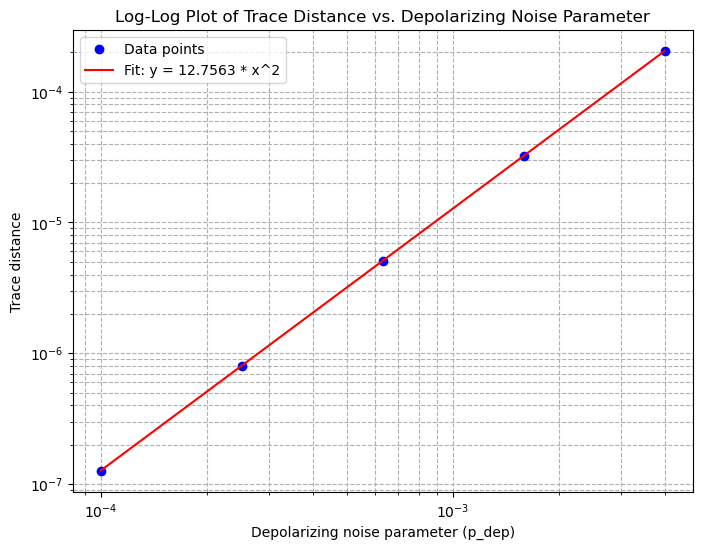

In [ ]:
# Example data
# p_dep_values = np.logspace(-4, np.log10(4e-3), num=10)
# trace_distances = [0.0001, 0.0002, 0.0004, 0.0008, 0.0016, 0.0032, 0.0064, 0.0128, 0.0256, 0.0512]

# Define the quadratic model y = k * x^2
def quadratic_model(x, k):
    return k * x**2

# Fit the model to the data
params, _ = curve_fit(quadratic_model, p_dep_values, trace_distances_pi8_naive)
k = params[0]

# Generate the fitting curve
fitting_curve = quadratic_model(p_dep_values, k)

# Create the log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(p_dep_values, trace_distances_pi8_naive, 'bo', label='Data points')
plt.loglog(p_dep_values, fitting_curve, 'r-', label=f'Fit: y = {k:.4f} * x^2')
plt.xlabel('Depolarizing noise parameter (p_dep)')
plt.ylabel('Trace distance')
plt.title('Log-Log Plot of Trace Distance vs. Depolarizing Noise Parameter')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Main: plot output

$\chi = 2\pi\cdot 5 $ MHz;     
$\Omega = 2\pi\cdot 20 $ MHz

$\varphi = \pi/8, \pi/4$

Ancille-free, ancilla case

In [5]:
# calculate the propagator of the dispersive coupling procedure
def Propagator_ZZrotNaiveNoisy(phi:float, chi_ZZ: float, kappa0:float) -> Qobj:
    '''
    Calculate the propagator of the ancilla-free noisy ZZ rotation gate.

    Parameters:
    -----------------------------------
    Input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    
    Output:
    L_naiveZZrot: ([2,2]*[2,2])*([2,2]*[2,2]) Qobj: the Liouville matrix to store the propagator
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_12 = -chi_ZZ*tensor( sigmaz(), sigmaz() )

    # (normalized) jump operators
    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1))

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-11, rtol=1e-11)
    
    # then perform the first-round dispersive coupling ZZ gates 
    # times = np.linspace(0, (phi/chi_ZZ), 1000)
    # result = mesolve(HZZ_12, rho0, times, c_ops, [], options=options)
    # rho1 = result.states[-1].unit()

    time = phi/chi_ZZ

    L_naiveZZrot = propagator(HZZ_12, time, c_ops, [], options=options)

    return L_naiveZZrot


#### Ancilla-free case: store the data

In [6]:
## Define the noisy circuit for the |m_\phi> state prepraration
# circuit to generate the output density matrix with given syndrome outcome
def circuit_generation_naive(p_dep:float, phi:float, kappa0:float,
                       chi_ZZ:float = 2*np.pi*4.8e6, Omega:float = 2*np.pi*20.4e6) -> tuple[dict[str, DensityMatrix], dict[str, float]]:
    # Step 1: Build the ideal circuit
    qubits = np.array(range(8)) 
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    cr = np.zeros((1,4))   # register for the intermediate circuit measurement

    qc = QuantumCircuit(8)
    # plus state preparation
    for q in data:
        qc.reset(q)
    qc.h(data[0])
    qc.h(data[2])
    qc.id(data[1])
    qc.id(data[3])
    qc.cx(data[0],data[1])
    qc.cx(data[2],data[3])

    # add ZZ rotation gate here
    # zz_gate = RZZGate(-2 * phi)
    # qc.append(zz_gate, [data[0], data[2]])
    L_naiveZZrot = Propagator_ZZrotNaiveNoisy(phi, chi_ZZ, kappa0)
    kraus_ops = to_kraus(L_naiveZZrot)
    kraus_matrices = [k.full() for k in kraus_ops]  # Convert Qobj to NumPy
    kraus_gate = Kraus(kraus_matrices)
    qc.append(kraus_gate, [data[0], data[2]])

    # ZX-QED
    # t-1 (can be done with former circuits)
    qc.reset(ancilla[0])
    qc.reset(ancilla[1])
    # t0
    qc.cx(data[0],ancilla[0])
    qc.cx(data[2],ancilla[1])
    qc.id(data[1])
    qc.id(data[3])
    qc.reset(ancilla[2])
    qc.reset(ancilla[3])
    # t1
    qc.cx(data[1],ancilla[0])
    qc.cx(data[3],ancilla[1])
    qc.id(data[0])
    qc.id(data[2])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t2
    # qc.measure(ancilla[0],cr[0])
    # qc.measure(ancilla[1],cr[1])
    qc.cx(ancilla[2],data[0])
    qc.cx(ancilla[3],data[1])
    qc.id(data[2])
    qc.id(data[3])
    # t3
    qc.id(data[0])
    qc.id(data[1])
    qc.cx(ancilla[2],data[2])
    qc.cx(ancilla[3],data[3])
    # t4
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])
    qc.id(data[3])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t5
    # qc.measure(ancilla[2],cr[2])
    # qc.measure(ancilla[3],cr[3]) # postpone all the measurements

    # Step 2: Add noise

    # QuantumError objects
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'])

    # append ZZ noise as an instruction (CP non-TP channel)
    # chi_matrix = ZZnoisyNaive_chi_matrix(phi, chi_ZZ, Omega, kappa0)  # pfail_ZZ here is useless
    # kraus_operators = chi_to_kraus(chi_matrix)
    # kraus_channel = Kraus(kraus_operators)
    # zz_error = QuantumError(kraus_channel)
    # noise_model.add_quantum_error(zz_error, zz_gate.name, [data[0], data[2]])  # note that this error is non-TP!
    
    
    # Step 3: Simulate the circuit to get the density matrix
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    qc.save_density_matrix()
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    rho = result.data(0)['density_matrix']

    # Step 4: Convert to Qiskit's DensityMatrix object
    dm = DensityMatrix(rho)

    # Step 5: Measure qubits 0, 1, 6, 7 in Z basis
    # Simulate measurement by projecting onto computational basis states
    def project_and_trace(dm: DensityMatrix, outcome: str, measured_qubits: list[int]) -> tuple[DensityMatrix, float]:
        """Project onto a computational basis outcome and trace out measured qubits."""
        from qiskit.quantum_info import partial_trace, Statevector
        n = dm.num_qubits
        outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
        projector = np.zeros((2**n, 2**n), dtype=complex)
        for i in range(2**n):
            bits = format(i, f'0{n}b')
            bits = bits[::-1]
            if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
                projector[i, i] = 1
        projected_dm = projector @ dm.data @ projector
        norm = np.trace(projected_dm.data)
        if norm > 0:
            projected_dm = DensityMatrix(projected_dm.data / norm)
            reduced_dm = partial_trace(projected_dm, measured_qubits)
            return reduced_dm, norm
        else:
            return None, 0

    # Step 6: Post-select on outcomes '0000' and '0011'
    measured_qubits = [ancilla[0], ancilla[1], ancilla[2], ancilla[3]]
    outcomes = {'0000': 0b0000, '0011': 0b0011}
    reduced_dms = {}
    prob_list={}

    for label, outcome in outcomes.items():
        reduced_dm, norm = project_and_trace(dm, outcome, measured_qubits)
        if reduced_dm:
            reduced_dms[label] = reduced_dm
            prob_list[label] = np.real(norm)
    
    return reduced_dms, prob_list

# project the state to the code space
def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None) -> tuple[DensityMatrix,float]:
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0

# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm:DensityMatrix, pauli:Pauli) -> float:
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm:DensityMatrix, logical_paulis:Pauli) -> DensityMatrix:
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)

# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(ph:float) -> DensityMatrix:
    plus = np.array([[1], [1]]) / np.sqrt(2)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Compute trace distance
def trace_distance(rho:DensityMatrix, sigma:DensityMatrix) -> float:
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.real( np.sum(np.abs(eigvals)) )

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X

In [7]:
# Sweep p_dep and compute trace distances
# phi = np.pi / 4
phi = np.pi/8
# chi_ZZ:float = 2*np.pi*4.8e6
# Omega:float = 2*np.pi*20.4e6
chi_ZZ:float = 2*np.pi*5e6
Omega:float = 2*np.pi*20e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep_values = np.logspace(np.log10(3e-4), np.log10(3e-3), num=20)
trace_distances_pi8_naive = []

for p_dep in p_dep_values:
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation_naive(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'0000','0011'}
    stab_value_dict = {'0000':[0,0,0], '0011':[1,1,0]}
    trace_distance_dict= {'0000':0, '0011':0}
    cond_prob_dict = {'0000':prob_list['0000']/success_prob, '0011':prob_list['0011']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi8_naive.append(distance)

phi = np.pi/4
ideal_dm = ideal_state_density_matrix(phi)
trace_distances_pi4_naive = []
for p_dep in p_dep_values:
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation_naive(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'0000','0011'}
    stab_value_dict = {'0000':[0,0,0], '0011':[1,1,0]}
    trace_distance_dict= {'0000':0, '0011':0}
    cond_prob_dict = {'0000':prob_list['0000']/success_prob, '0011':prob_list['0011']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi4_naive.append(distance)


# Output results
print("Noise parameters (p_dep):", p_dep_values)
print("Trace distances:", trace_distances_pi8_naive)

C:\Users\zengp\AppData\Roaming\Python\Python311\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Noise parameters (p_dep): [0.0003     0.00033865 0.00038228 0.00043153 0.00048713 0.00054989
 0.00062074 0.00070072 0.000791   0.00089291 0.00100795 0.00113781
 0.0012844  0.00144988 0.00163668 0.00184754 0.00208558 0.00235428
 0.0026576  0.003     ]
Trace distances: [np.float64(3.538831485055553e-07), np.float64(4.5098461541028533e-07), np.float64(5.747423556256463e-07), np.float64(7.324779411001494e-07), np.float64(9.335256398193951e-07), np.float64(1.1897864527357074e-06), np.float64(1.5164349896238325e-06), np.float64(1.932820118018377e-06), np.float64(2.4636204233729796e-06), np.float64(3.140309687174948e-06), np.float64(4.003034295912669e-06), np.float64(5.103010382937284e-06), np.float64(6.505585245680326e-06), np.float64(8.294150095532226e-06), np.float64(1.0575142070400305e-05), np.float64(1.3484440980352159e-05), np.float64(1.7195556664741314e-05), np.float64(2.1930104399723026e-05), np.float64(2.7971229296365634e-05), np.float64(3.568080915539641e-05)]


#### Ancilla case

In [8]:
# calculate the propagator of the dispersive coupling procedure
def Propagator_ZZrot_gfNoisy_extend(phi:float, chi_ZZ: float, Omega:float, kappa0:float) -> Qobj:
    '''
    Calculate the propagator of the ancilla-free noisy ZZ rotation gate.

    Parameters:
    -----------------------------------
    Input:
    phi: float: rotation angle, we set phi<np.pi/4    
    chi_ZZ: float: dispersive coupling strength
    Omega: float: g-f driving strength
    kappa0: float: noise level
    
    Output:
    L_gfZZrot: ([2,2,4]*[2,2,4])*([2,2,4]*[2,2,4]) Qobj: the Liouville matrix to store the propagator
    '''

    # noisy parameters
    # kappa0 = 1e3
    kappa_d, kappa_ph = kappa0, kappa0
    # p_prep = 1e-3  # state preparation error

    ## operators definition
    # Pauli operators on the three-level system: defined on the g, f levels
    # Extension: 0: 00 => 0; 1: 01 => 1; 2: 11 => 3
    Xgf = projection(4,0,3) + projection(4,3,0)
    Ygf = -1j*projection(4,0,3) + 1j*projection(4,3,0)
    Zgf = projection(4,0,0) - projection(4,3,3)

    # system Hamiltonians: all defined on 2 qubits and 1 qutrits
    HZZ_1anc = chi_ZZ*tensor( projection(2,1,1), identity(2), projection(4,3,3) )
    HZZ_2anc = chi_ZZ*tensor( identity(2), projection(2,1,1), projection(4,3,3) )
    HY_anc = Omega*tensor( identity(2), identity(2), Ygf )
    HX_anc = Omega*tensor( identity(2), identity(2), Xgf )

    # (normalized) jump operators
    # ancilla jump operators
    J_anc_fe = tensor(identity(2), identity(2), projection(4,1,3)) # f-> e decay without coupling
    J_anc_eg = tensor(identity(2), identity(2), projection(4,0,1)) # e-> g decay without coupling
    J_anc_ph = tensor(identity(2), identity(2), projection(4,1,1) + 2*projection(4,3,3))

    # data qubit 1 jump operators
    J_1_eg = tensor(projection(2,0,1), identity(2), identity(4)) # e-> g decay without coupling
    J_1_ph = tensor(projection(2,1,1), identity(2), identity(4))

    # data qubit 2 jump operators
    J_2_eg = tensor(identity(2), projection(2,0,1), identity(4)) # e-> g decay without coupling
    J_2_ph = tensor(identity(2), projection(2,1,1), identity(4))


    # # ancilla (noisy) initial state preparation
    # rho_anc0 = (1-p_prep)*projection(3,0,0) + p_prep*projection(3,1,1)
    # rho_ini = tensor(rho0, rho_anc0)  # the global initial state

    # Collapse operators
    c_ops = [
        np.sqrt(kappa_d) * J_anc_fe,
        np.sqrt(kappa_d) * J_anc_eg,
        np.sqrt(kappa_ph) * J_anc_ph,
        np.sqrt(kappa_d) * J_1_eg,
        np.sqrt(kappa_ph) * J_1_ph,
        np.sqrt(kappa_d) * J_2_eg,
        np.sqrt(kappa_ph) * J_2_ph,
    ]

    ## mesolve procedure
    options = Options(nsteps=10000, atol=1e-16, rtol=1e-16)
    # first convert the ancilla to the g+-f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(HY_anc, rho_ini, times, c_ops[0:3], [], options=options)# no data qubit noise: because we can perform this gate in advance
    # rho1 = result.states[-1].unit()
    time = (np.pi/4) / Omega
    L_step1 = propagator(HY_anc, time, c_ops[0:3], [], options=options)
    
    # then perform the first-round dispersive coupling ZZ gates 
    ''' 
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho1, times, c_ops, [], options=options)
    rho2 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho2, times, c_ops, [], options=options)
    rho3 = result.states[-1].unit() 
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho1, times, c_ops, [], options=options)
    # rho3 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step23 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)


    # then perform X-rotation on the ancillary 3-level system
    # times = np.linspace(0, (phi/Omega), 1000)
    # result = mesolve(-HX_anc, rho3, times, c_ops, [], options=options)
    # rho4 = result.states[-1].unit()
    time = phi/Omega
    L_step4 = propagator(-HX_anc, time, c_ops, [], options=options)


    # then perform the second-round dispersive coupling ZZ gates
    '''
    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_1anc, rho4, times, c_ops, [], options=options)
    rho5 = result.states[-1].unit()

    times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    result = mesolve(HZZ_2anc, rho5, times, c_ops, [], options=options)
    rho6 = result.states[-1].unit()
    '''
    # times = np.linspace(0, (np.pi/chi_ZZ), 1000)
    # result = mesolve(HZZ_1anc + HZZ_2anc, rho4, times, c_ops, [], options=options)
    # rho6 = result.states[-1].unit()
    time = (np.pi/chi_ZZ)
    L_step56 = propagator(HZZ_1anc + HZZ_2anc, time, c_ops, [], options=options)
    
    
    # finally convert the ancilla to the g e f basis
    # times = np.linspace(0, (np.pi/4) / Omega, 1000)
    # result = mesolve(-HY_anc, rho6, times, c_ops[0:3], [], options=options) # no data qubit noise: because we can perform this gate simultaneously with data qubit latter operations
    # rho7 = result.states[-1].unit()
    # rho12anc = rho7
    time = (np.pi/4) / Omega
    L_step7 = propagator(-HY_anc, time, c_ops[0:3], [], options=options)    

    L_gfZZrot = L_step7 * L_step56 * L_step4 * L_step23 * L_step1
    # L_gfZZrot = L_step1 * L_step23 * L_step4 * L_step56 * L_step7

    return L_gfZZrot

# Normlize the kraus operators
def normalize_kraus(kraus_ops:list[Qobj]) -> list[Qobj] :
    # Assume kraus_ops is your list of Qobj with shape (16, 16)
    # Example: kraus_ops = [Qobj(...), Qobj(...), ...]

    # Step 1: Compute the sum of K_i† K_i
    K_sum = sum([K.dag() * K for K in kraus_ops])

    # Step 2: Compute the inverse square root of K_sum
    K_sum_np = K_sum.full()  # Convert to NumPy array
    K_sum_inv_sqrt_np = sqrtm(inv(K_sum_np))  # Compute inverse square root
    K_sum_inv_sqrt = Qobj(K_sum_inv_sqrt_np, dims=K_sum.dims)  # Convert back to Qobj

    # Step 3: Renormalize each Kraus operator
    kraus_ops_renorm = [K * K_sum_inv_sqrt for K in kraus_ops]

    # Step 4 (Optional): Verify the normalization
    K_sum_renorm = sum([K.dag() * K for K in kraus_ops_renorm])
    identity_K = qeye(K_sum_renorm.shape[0])
    error = (Qobj(K_sum_renorm.full()) - identity_K).norm()

    return kraus_ops_renorm

def reverse_qubit_order_in_kraus(kraus_matrices):
    num_qubits = 4
    dim = 2 ** num_qubits

    # Compute permutation indices for reversed bit strings
    perm = [int(format(i, f'0{num_qubits}b')[::-1], 2) for i in range(dim)]

    # Create permutation matrix
    P = np.eye(dim)[perm]

    # Apply permutation: P * K * P†
    reversed_kraus = [P @ K @ P.T.conj() for K in kraus_matrices]

    return reversed_kraus

## Define the noisy circuit for the |m_\phi> state prepraration
# circuit to generate the output density matrix with given syndrome outcome
def circuit_generation(p_dep:float, phi:float, kappa0:float,
                       chi_ZZ:float = 2*np.pi*4.8e6, Omega:float = 2*np.pi*20.4e6) -> tuple[dict[str, DensityMatrix], dict[str, float]]:
    # Step 1: Build the ideal circuit
    qubits = np.array(range(10))  # the final two qubits is used to flag the ZZ rotation gate; 00: 0, 01: 1, 11: 2
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    ancillaZZ = qubits[8:10]  # the 3-level ancilla for ZZrot gate
    cr = np.zeros((1,4))   # register for the intermediate circuit measurement

    qc = QuantumCircuit(10)
    # plus state preparation
    for q in data:
        qc.reset(q)
    qc.h(data[0])
    qc.h(data[2])
    qc.id(data[1])
    qc.id(data[3])
    qc.cx(data[0],data[1])
    qc.cx(data[2],data[3])

    # add ZZ rotation gate here
    # zz_gate = RZZGate(-2 * phi)
    # qc.append(zz_gate, [data[0], data[2]])
    # qc.reset(ancillaZZ[0])
    # qc.reset(ancillaZZ[1])
    L_naiveZZrot = Propagator_ZZrot_gfNoisy_extend(phi, chi_ZZ, Omega, kappa0)
    kraus_ops = to_kraus(L_naiveZZrot)
    kraus_ops_renorm = normalize_kraus(kraus_ops)
    kraus_matrices = [k.full() for k in kraus_ops_renorm]  # Convert Qobj to NumPy
    reversed_kraus_matrices = reverse_qubit_order_in_kraus(kraus_matrices)
    kraus_gate = Kraus(reversed_kraus_matrices)
    qc.append(kraus_gate, [data[0], data[2], ancillaZZ[0], ancillaZZ[1]])

    # ZX-QED
    # t-1 (can be done with former circuits)
    qc.reset(ancilla[0])
    qc.reset(ancilla[1])
    # t0
    qc.cx(data[0],ancilla[0])
    qc.cx(data[2],ancilla[1])
    qc.id(data[1])
    qc.id(data[3])
    qc.reset(ancilla[2])
    qc.reset(ancilla[3])
    # t1
    qc.cx(data[1],ancilla[0])
    qc.cx(data[3],ancilla[1])
    qc.id(data[0])
    qc.id(data[2])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t2
    # qc.measure(ancilla[0],cr[0])
    # qc.measure(ancilla[1],cr[1])
    qc.cx(ancilla[2],data[0])
    qc.cx(ancilla[3],data[1])
    qc.id(data[2])
    qc.id(data[3])
    # t3
    qc.id(data[0])
    qc.id(data[1])
    qc.cx(ancilla[2],data[2])
    qc.cx(ancilla[3],data[3])
    # t4
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])
    qc.id(data[3])
    qc.h(ancilla[2])
    qc.h(ancilla[3])
    # t5
    # qc.measure(ancilla[2],cr[2])
    # qc.measure(ancilla[3],cr[3]) # postpone all the measurements

    # Step 2: Add noise

    # QuantumError objects
    noise_model = NoiseModel()
    # add single-qubit errors
    for qubit in np.concatenate((data, ancilla)).tolist():
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['h'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['id'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['reset'], [qubit])
        noise_model.add_quantum_error(depolarizing_error(p_dep, 1), ['measure'], [qubit])

    # add two-qubit errors
    for q1 in np.concatenate((data, ancilla)).tolist():
        for q2 in np.concatenate((data, ancilla)).tolist():
            noise_model.add_quantum_error(depolarizing_error(p_dep, 2), ['cx'], [q1, q2])

    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['h'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 2), ['cx'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['id'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['reset'] )
    # noise_model.add_all_qubit_quantum_error(depolarizing_error(p_dep, 1), ['measure'] )

    # Step 3: Simulate the circuit to get the density matrix
    sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    qc.save_density_matrix()
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    rho = result.data(0)['density_matrix']

    # Step 4: Convert to Qiskit's DensityMatrix object
    dm = DensityMatrix(rho)

    # Step 5: Measure qubits 0, 1, 6, 7; 8, 9 in Z basis
    # Simulate measurement by projecting onto computational basis states
    def project_and_trace(dm: DensityMatrix, outcome: str, measured_qubits: list[int]) -> tuple[DensityMatrix, float]:
        """Project onto a computational basis outcome and trace out measured qubits."""
        from qiskit.quantum_info import partial_trace, Statevector
        n = dm.num_qubits
        outcome_bin = format(outcome, f'0{len(measured_qubits)}b')
        projector = np.zeros((2**n, 2**n), dtype=complex)
        for i in range(2**n):
            bits = format(i, f'0{n}b')
            bits = bits[::-1]
            if all(bits[q] == b for q, b in zip(measured_qubits, outcome_bin)):
                projector[i, i] = 1
        projected_dm = projector @ dm.data @ projector
        norm = np.trace(projected_dm.data)
        if norm > 0:
            projected_dm = DensityMatrix(projected_dm.data / norm)
            reduced_dm = partial_trace(projected_dm, measured_qubits)
            return reduced_dm, norm
        else:
            return None, 0

    # Step 6: Post-select on outcomes '000000' and '001100'
    measured_qubits = [0, 1, 6, 7, 8, 9]
    outcomes = {'000000': 0b000000, '001100': 0b001100}
    reduced_dms = {}
    prob_list={}

    for label, outcome in outcomes.items():
        reduced_dm, norm = project_and_trace(dm, outcome, measured_qubits)
        if reduced_dm:
            reduced_dms[label] = reduced_dm
            prob_list[label] = np.real(norm)
    
    return reduced_dms, prob_list

# project the state to the code space
def projective_measurement(dm: DensityMatrix, stabilizers: list[Pauli], stab_values: list[int] = None) -> tuple[DensityMatrix,float]:
    """Project a density matrix onto the stabilizer code space.

    stab_values should be the same length as stabilizers
    """

    n = dm.num_qubits
    projector = np.eye(2**n, dtype=complex)

    if stab_values == None:
        stab_values= [0 for _ in range(len(stabilizers))]

    if len(stab_values) != len(stabilizers):
        raise ValueError("Need a stab_values string with the same length of stabilizers!")
    
    for id_stab, stab in enumerate(stabilizers):
        projector = projector @ (np.eye(2**n) + (-1)**(stab_values[id_stab]) * stab.to_matrix()) / 2

    # Apply the projector
    projected = projector @ dm.data @ projector
    prob = np.trace(projected).real

    if prob > 0:
        normalized = projected / prob
        return DensityMatrix(normalized), prob
    else:
        return None, 0.0

# Define the logical Pauli operators
logical_paulis = {
    'X': Pauli('XXII'),
    'Y': Pauli('YXZI'),
    'Z': Pauli('ZIZI')
}

def expectation_value(dm:DensityMatrix, pauli:Pauli) -> float:
    """Calculate the expectation value of a Pauli operator."""
    return np.trace(dm.data @ pauli.to_matrix()).real

def logical_subspace_tomography(dm:DensityMatrix, logical_paulis:Pauli) -> DensityMatrix:
    """Reconstruct the logical qubit density matrix from logical Pauli expectations."""
    exp_vals = {label: expectation_value(dm, op) for label, op in logical_paulis.items()}
    
    # Build the logical density matrix: ρ = ½ (I + xX + yY + zZ)
    rho_logical = 0.5 * (
        np.eye(2)
        + exp_vals['X'] * np.array([[0, 1], [1, 0]])
        + exp_vals['Y'] * np.array([[0, -1j], [1j, 0]])
        + exp_vals['Z'] * np.array([[1, 0], [0, -1]])
    )
    
    return DensityMatrix(rho_logical)

# Define the ideal state Rz(phi)|+>
def ideal_state_density_matrix(ph:float) -> DensityMatrix:
    plus = np.array([[1], [1]]) / np.sqrt(2)
    rz = np.array([[np.exp(1j * phi), 0],
                   [0, np.exp(-1j * phi)]])
    state = rz @ plus
    return DensityMatrix(state @ state.conj().T)

# Compute trace distance
def trace_distance(rho:DensityMatrix, sigma:DensityMatrix) -> float:
    diff = rho.data - sigma.data
    eigvals = np.linalg.eigvals(diff)
    return 0.5 * np.real( np.sum(np.abs(eigvals)) )

# Define the stabilizer generators
stabilizers = [
    Pauli('XIXI'),
    Pauli('IXIX'),
    Pauli('ZZZZ')
]  # gauge qubit is fixed to X

In [9]:
# Sweep p_dep and compute trace distances
# phi = np.pi / 4
phi = np.pi/8
# chi_ZZ:float = 2*np.pi*4.8e6
# Omega:float = 2*np.pi*20.4e6
chi_ZZ:float = 2*np.pi*5e6
Omega:float = 2*np.pi*20e6

ideal_dm = ideal_state_density_matrix(phi)
p_dep_values = np.logspace(np.log10(3e-4), np.log10(3e-3), num=20)
trace_distances_pi8_ancilla = []

for id_pdep, p_dep in enumerate(p_dep_values):
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'000000','001100'}
    stab_value_dict = {'000000':[0,0,0], '001100':[1,1,0]}
    trace_distance_dict= {'000000':0, '001100':0}
    cond_prob_dict = {'000000':prob_list['000000']/success_prob, '001100':prob_list['001100']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi8_ancilla.append(distance)

    print(f"id={id_pdep}, p_dep={p_dep}")

phi = np.pi/4
ideal_dm = ideal_state_density_matrix(phi)
trace_distances_pi4_ancilla = []

for id_pdep, p_dep in enumerate(p_dep_values):
    # circuit_generation(p_dep:float) -> tuple[dict[str, DensityMatrix], dict[str, float]]

    kappa0 = p_dep*2e7

    reduced_dms, prob_list = circuit_generation(p_dep, phi, kappa0, chi_ZZ, Omega)
    
    success_prob = sum(prob_list.values())
    failure_prob = 1 - success_prob
    
    outcomes = {'000000','001100'}
    stab_value_dict = {'000000':[0,0,0], '001100':[1,1,0]}
    trace_distance_dict= {'000000':0, '001100':0}
    cond_prob_dict = {'000000':prob_list['000000']/success_prob, '001100':prob_list['001100']/success_prob}

    distance = 0
    for outcome in outcomes:
        post_dm, prob_post = projective_measurement(reduced_dms[outcome], stabilizers, stab_values = stab_value_dict[outcome])
        logical_dm = logical_subspace_tomography(post_dm, logical_paulis)
        distance += cond_prob_dict[outcome] * trace_distance(logical_dm, ideal_dm)

    trace_distances_pi4_ancilla.append(distance)

    print(f"id={id_pdep}, p_dep={p_dep}")

# Output results
print("Noise parameters (p_dep):", p_dep_values)
print("Trace distances:", trace_distances_pi4_ancilla)

id=0, p_dep=0.00030000000000000014
id=1, p_dep=0.00033865136750540695
id=2, p_dep=0.0003822824957109402
id=3, p_dep=0.00043153496648629905
id=4, p_dep=0.0004871330217566165
id=5, p_dep=0.0005498942132497309
id=6, p_dep=0.0006207414243344372
id=7, p_dep=0.0007007164407270367
id=8, p_dep=0.0007909952696191077
id=9, p_dep=0.0008929054324893961
id=10, p_dep=0.0010079454858851348
id=11, p_dep=0.0011378070572196754
id=12, p_dep=0.0012843997196158193
id=13, p_dep=0.001449879071571526
id=14, p_dep=0.0016366784343505565
id=15, p_dep=0.0018475446331980808
id=16, p_dep=0.0020855783885326824
id=17, p_dep=0.002354279911054383
id=18, p_dep=0.002657600371230248
id=19, p_dep=0.003000000000000001
id=0, p_dep=0.00030000000000000014
id=1, p_dep=0.00033865136750540695
id=2, p_dep=0.0003822824957109402
id=3, p_dep=0.00043153496648629905
id=4, p_dep=0.0004871330217566165
id=5, p_dep=0.0005498942132497309
id=6, p_dep=0.0006207414243344372
id=7, p_dep=0.0007007164407270367
id=8, p_dep=0.0007909952696191077
id

#### Plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


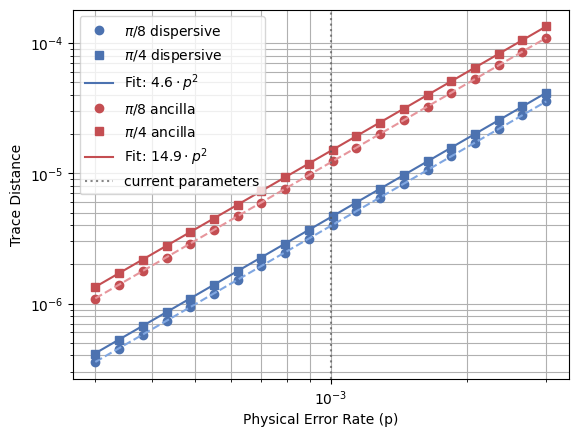

In [16]:
# Define the fitting function
def power_law(x, a):
    return a * x**2

# Create the plot
# plt.figure(figsize=(10, 6))

# Color scheme
colors = {
    'dispersive': '#4C72B0',  # Soft blue
    'dispersive_light': '#7FA6E1',  # Lighter blue
    'ancilla': '#C44E52',  # Soft red
    'ancilla_light': '#E7969C'  # Lighter pink
}

# Plot and fit pi/8 naive
plt.loglog(p_dep_values, trace_distances_pi8_naive, 'o', color=colors['dispersive'], label='$\pi$/8 dispersive')
params_pi8_naive, _ = curve_fit(power_law, p_dep_values, trace_distances_pi8_naive)
plt.loglog(p_dep_values, power_law(p_dep_values, *params_pi8_naive), '--', color=colors['dispersive_light'])

# Plot and fit pi/4 naive
plt.loglog(p_dep_values, trace_distances_pi4_naive, 's', color=colors['dispersive'], label='$\pi$/4 dispersive')
params_pi4_naive, _ = curve_fit(power_law, p_dep_values, trace_distances_pi4_naive)
plt.loglog(p_dep_values, power_law(p_dep_values, *params_pi4_naive), '-', color=colors['dispersive'], label=f'Fit: $ {params_pi4_naive[0]:.1f}  \cdot p^2$')

# Plot and fit pi/8 ancilla
plt.loglog(p_dep_values, trace_distances_pi8_ancilla, 'o', color=colors['ancilla'], label='$\pi$/8 ancilla')
params_pi8_ancilla, _ = curve_fit(power_law, p_dep_values, trace_distances_pi8_ancilla)
plt.loglog(p_dep_values, power_law(p_dep_values, *params_pi8_ancilla), '--', color=colors['ancilla_light'])

# Plot and fit pi/4 ancilla
plt.loglog(p_dep_values, trace_distances_pi4_ancilla, 's', color=colors['ancilla'], label='$\pi$/4 ancilla')
params_pi4_ancilla, _ = curve_fit(power_law, p_dep_values, trace_distances_pi4_ancilla)
plt.loglog(p_dep_values, power_law(p_dep_values, *params_pi4_ancilla), '-', color=colors['ancilla'], label=f'Fit: $ {params_pi4_ancilla[0]:.1f} \cdot p^2$')

# Add vertical line at p_dep = 1e-3
plt.axvline(x=1e-3, color='#555555', linestyle=':', linewidth=1.5, alpha=0.7, label='current parameters')

# Add labels and legend
plt.xlabel('Physical Error Rate (p)')
plt.ylabel('Trace Distance')
plt.legend()
plt.grid(True, which="both", ls="-")

# Save as EPS file
plt.savefig('Num4112coherent251120.eps', format='eps', dpi=1000, bbox_inches='tight')

plt.show()